# Light Rail Passenger Forecasting — Porto Metro (2012–2026)



## 1. Introduction



In [1]:
from pathlib import Path
import warnings
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scipy.stats as stats
import matplotlib.ticker as ticker

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.api import Holt, ExponentialSmoothing

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 200)


In [2]:

# Paths and constants
project_root = Path('..')
data_path = project_root / 'data' / 'light_rail_passengers.xlsx'
output_dir = project_root / 'outputs'
fig_dir = output_dir / 'figures'
data_out_dir = output_dir / 'data'
tables_dir = output_dir / 'tables'
diagnostics_dir = output_dir / 'diagnostics'

for d in [fig_dir, data_out_dir, tables_dir, diagnostics_dir]:
    d.mkdir(parents=True, exist_ok=True)

VALIDATION_YEAR = 2025
FORECAST_YEAR = 2026
SEASONAL_PERIOD = 12
HORIZON = 12


## 2. Data and Preprocessing

### 2.1 Data Preparation



In [3]:
MONTH_MAP_PT = {
    'janeiro': 1, 'fevereiro': 2, 'março': 3, 'marco': 3, 'abril': 4,
    'maio': 5, 'junho': 6, 'julho': 7, 'agosto': 8, 'setembro': 9,
    'outubro': 10, 'novembro': 11, 'dezembro': 12
}

# Data start: exclude pre-2012 early adoption ramp-up (unstable seasonal pattern, low base)
SERIES_START = pd.Timestamp('2012-01-01')

def parse_ine_monthly_series(path: Path) -> pd.Series:
    raw = pd.read_excel(path, header=None).rename(columns={0: 'period_text', 1: 'value'})
    mask = raw['period_text'].astype(str).str.contains(r'de\s+\d{4}', regex=True, na=False)
    df = raw.loc[mask, ['period_text', 'value']].copy()
    df['period_text'] = df['period_text'].astype(str).str.strip().str.lower()

    def parse_period(text: str):
        m = re.match(r'^([a-záàâãéêíóôõúç]+)\s+de\s+(\d{4})$', text)
        if not m:
            return pd.NaT
        month_name, year = m.group(1), int(m.group(2))
        month = MONTH_MAP_PT.get(month_name)
        if month is None:
            return pd.NaT
        return pd.Timestamp(year=year, month=month, day=1)

    df['Date'] = df['period_text'].map(parse_period)
    df['value'] = pd.to_numeric(df['value'], errors='coerce')
    df = df.dropna(subset=['Date', 'value']).sort_values('Date')

    series = pd.Series(df['value'].values, index=pd.DatetimeIndex(df['Date']), name='Passengers')
    return series.asfreq('MS')

raw_series = parse_ine_monthly_series(data_path)

# Drop pre-2012 early adoption period (96 months, unstable ramp-up phase)
n_dropped = (raw_series.index < SERIES_START).sum()
raw_series = raw_series.loc[SERIES_START:]

# Quantify repaired values before interpolation
n_missing_raw = raw_series.isna().sum()
n_zero_raw = (raw_series == 0).sum()
n_repaired = n_missing_raw + n_zero_raw

series = raw_series.replace(0, np.nan).interpolate(method='time').bfill().ffill()

print(f'Dropped pre-2012 observations: {n_dropped}  (2004-01 to 2011-12 early adoption ramp-up)')
print(f'Observations after trimming: {len(series)}')
print(f'Period: {series.index.min().date()} -> {series.index.max().date()}')
print(f'Missing before repair: {n_missing_raw}  |  Zero values replaced: {n_zero_raw}  |  Total repaired: {n_repaired}')
print(f'Missing after repair: {series.isna().sum()}')
print(f'Min value: {series.min():.0f}  (at {series.idxmin().date()})  |  Mean: {series.mean():.0f}  |  Std: {series.std():.0f}')
series.tail()


Dropped pre-2012 observations: 96  (2004-01 to 2011-12 early adoption ramp-up)
Observations after trimming: 168
Period: 2012-01-01 -> 2025-12-01
Missing before repair: 0  |  Zero values replaced: 1  |  Total repaired: 1
Missing after repair: 0
Min value: 1423  (at 2020-05-01)  |  Mean: 5295  |  Std: 1446


Date
2025-08-01    6840.0
2025-09-01    8274.0
2025-10-01    9284.0
2025-11-01    8244.0
2025-12-01    7123.0
Freq: MS, Name: Passengers, dtype: float64

In [4]:
train_end = pd.Timestamp(f"{VALIDATION_YEAR-1}-12-01")
val_start = pd.Timestamp(f"{VALIDATION_YEAR}-01-01")
val_end   = pd.Timestamp(f"{VALIDATION_YEAR}-12-01")

## 3. Exploratory Data Analysis

### 3.1 Time Series Features



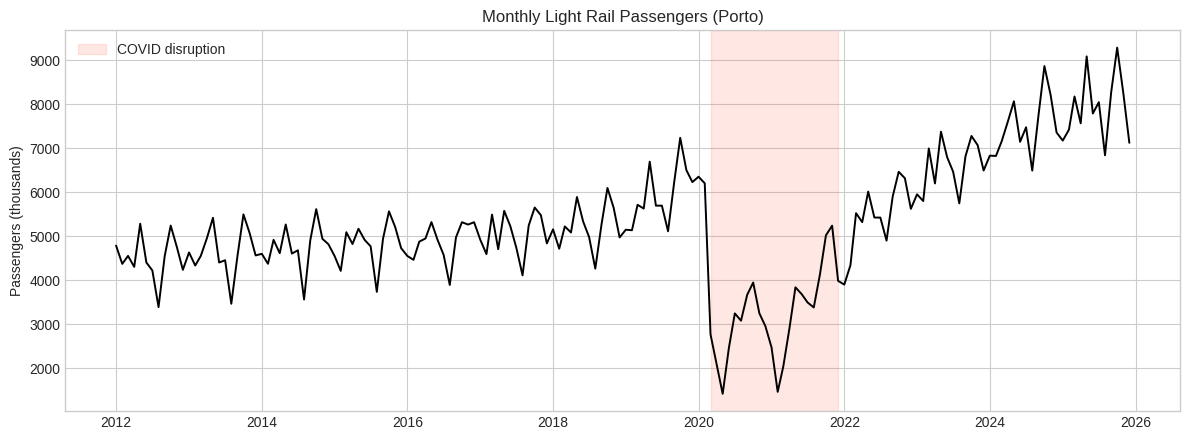

In [5]:

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(series.index, series.values, color='black', linewidth=1.4)
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-01'), color='tomato', alpha=0.15, label='COVID disruption')
ax.set_title('Monthly Light Rail Passengers (Porto)')
ax.set_ylabel('Passengers (thousands)')
ax.legend()
plt.tight_layout()
plt.savefig(fig_dir / 'eda_time_plot.png', dpi=300)
plt.show()


In [6]:

# Seasonal profile by month
month_profile = series.groupby(series.index.month).agg(['mean', 'median'])
month_profile.index = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_profile


,mean,median
Jan,5075.428571,4855.5
Feb,4877.357143,4530.5
Mar,5221.928571,5158.5
Apr,5055.888759,4956.5
May,5745.857143,5499.5
Jun,5201.285714,5072.5
Jul,5163.571429,4755.0
Aug,4428.642857,4004.0
Sep,5515.857143,5110.0
Oct,6221.285714,5635.5


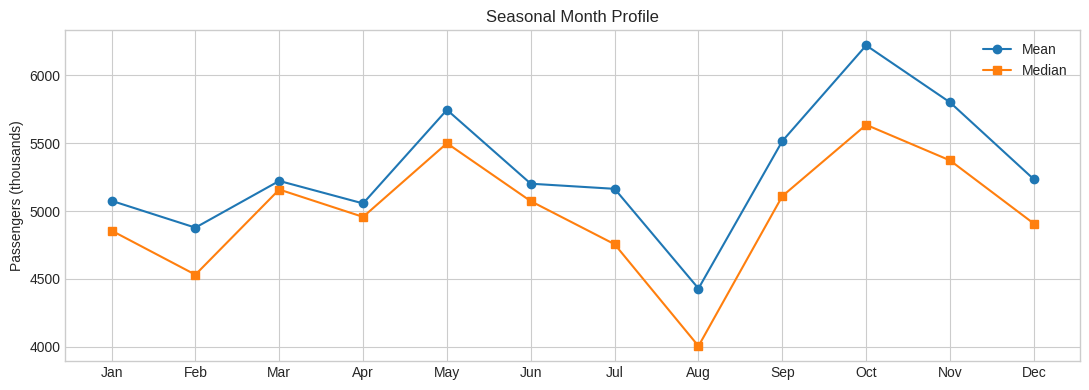

In [7]:

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(month_profile.index, month_profile['mean'], marker='o', label='Mean')
ax.plot(month_profile.index, month_profile['median'], marker='s', label='Median')
ax.set_title('Seasonal Month Profile')
ax.set_ylabel('Passengers (thousands)')
ax.legend()
plt.tight_layout()
plt.savefig(fig_dir / 'eda_month_profile.png', dpi=300)
plt.show()


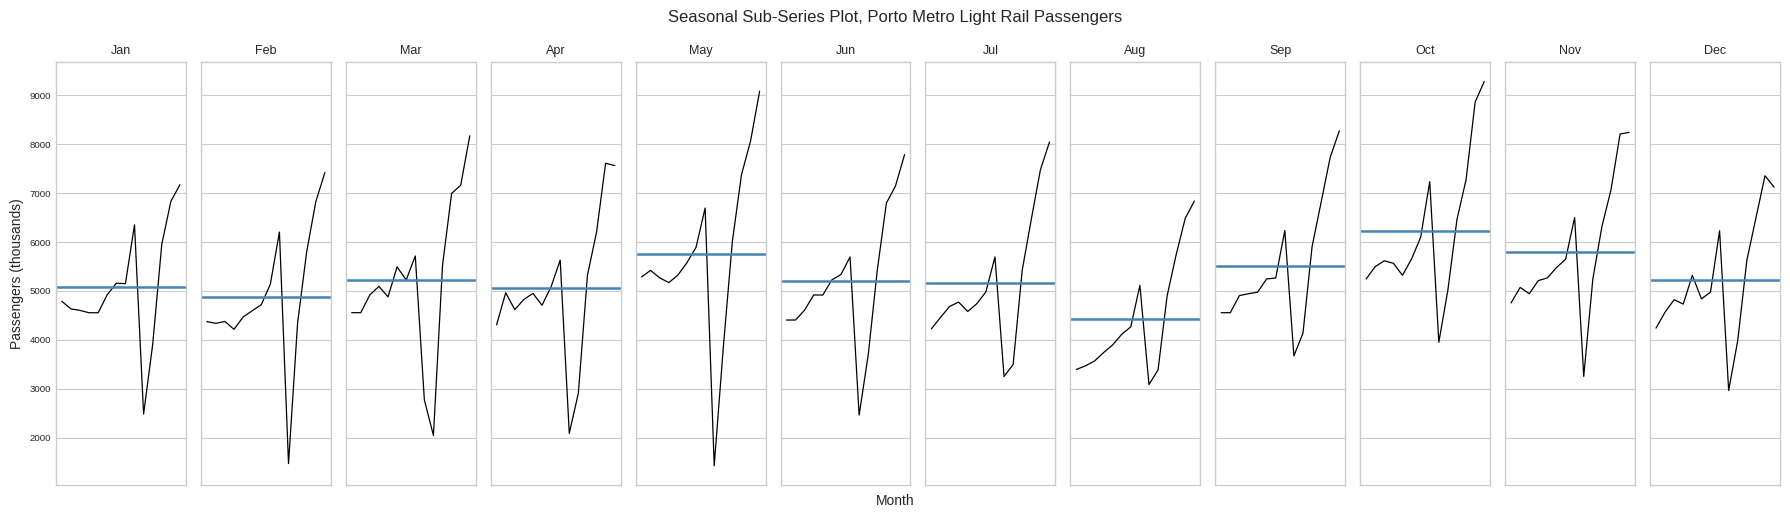

In [8]:
# Seasonal sub-series plot
# Each panel shows one calendar month across all years; horizontal bar = within-month mean
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 12, figsize=(18, 5), sharey=True)
fig.suptitle('Seasonal Sub-Series Plot, Porto Metro Light Rail Passengers', fontsize=12)

for i, (ax, mname) in enumerate(zip(axes, month_names), start=1):
    month_data = series[series.index.month == i]
    ax.plot(range(len(month_data)), month_data.values, color='black', linewidth=0.9)
    ax.axhline(month_data.mean(), color='steelblue', linewidth=1.8)
    ax.set_title(mname, fontsize=9)
    ax.set_xticks([])
    if i == 1:
        ax.set_ylabel('Passengers (thousands)')
    ax.tick_params(axis='y', labelsize=7)

fig.text(0.5, -0.01, 'Month', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig(fig_dir / 'eda_seasonal_subseries.png', dpi=300, bbox_inches='tight')
plt.show()


### 3.2 COVID Adjustment and Model Counterfactuals



--- ESTIMATION RESULTS: HOLT-WINTERS ---
                       ExponentialSmoothing Model Results                       
Dep. Variable:               Passengers   No. Observations:                   84
Model:             ExponentialSmoothing   SSE                        2064470.101
Optimized:                         True   AIC                            881.204
Trend:                         Additive   BIC                            920.097
Seasonal:                      Additive   AICC                           891.727
Seasonal Periods:                    12   Date:                 Mon, 15 Jun 2026
Box-Cox:                          False   Time:                         10:04:51
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level              1.4901e-08                alpha      

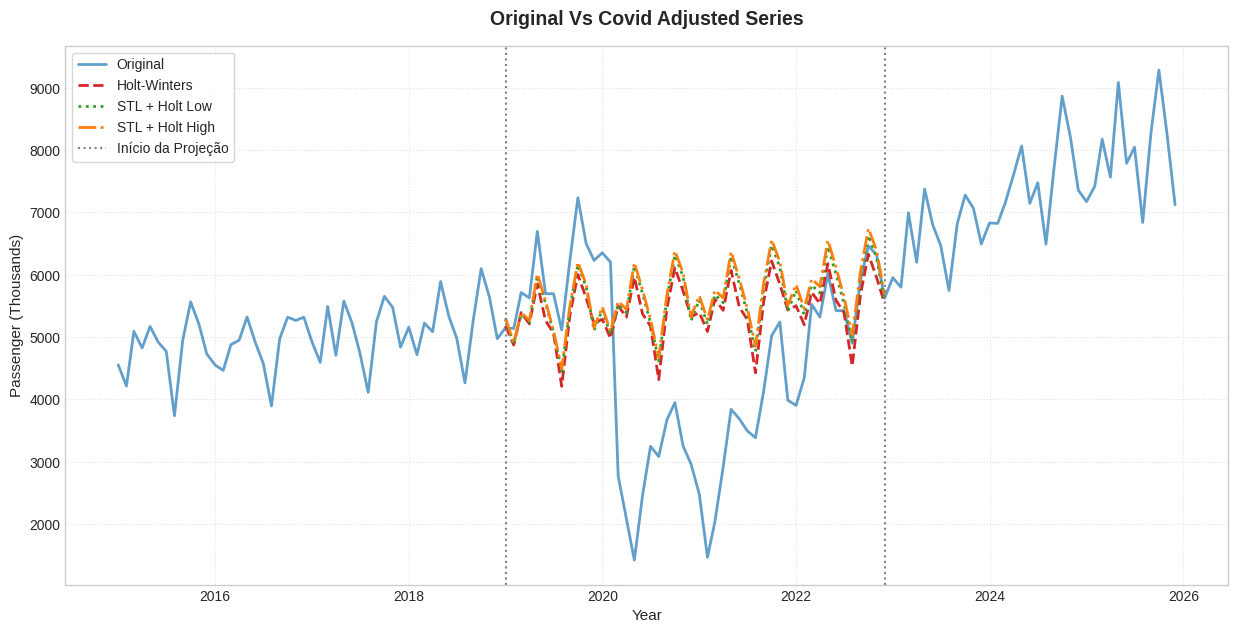

📸 Gráfico guardado com sucesso em: ../outputs/figures/comparativo_modelos_covid.png
📊 Tabelas exportadas com sucesso em: ../outputs/tables


In [9]:
# ==========================================
# 0. CONFIGURATION & DIRECTORY PATHS
# ==========================================
# Set up output directories
table_path = tables_dir
fig_path = fig_dir

# Create directories dynamically if they do not exist
table_path.mkdir(parents=True, exist_ok=True)
fig_path.mkdir(parents=True, exist_ok=True)


# ==========================================
# 1. ESTIMATION & PARAMETERS (2012-2018)
# ==========================================
# Train models on baseline data prior to 2019 projection window
treino = series.loc["2012-01-01":"2018-12-31"]

# Adjust Smoothing Exponential Holt-Winters model
modelo_hw = ExponentialSmoothing(
    treino, trend="add", seasonal="add", seasonal_periods=12
)
resultado_hw = modelo_hw.fit()

print("--- ESTIMATION RESULTS: HOLT-WINTERS ---")
print(resultado_hw.summary())

# Parameters alpha, beta e gamma:
parametros = resultado_hw.params
print("\nOptimum Parameters Estimated:")
print(f"Alpha (Level): {parametros['smoothing_level']:.4f}")
print(f"Beta (Trend): {parametros['smoothing_trend']:.4f}")
print(f"Gamma (Seazonality): {parametros['smoothing_seasonal']:.4f}")

# Finding seasonally adjusted data
df_smoothing = pd.DataFrame(
    {
        "Real_Observed": treino,
        "Smoothed_Fits": resultado_hw.fittedvalues,
        "Seasonally_Adjusted": treino / resultado_hw.season,
    },
    index=treino.index,
)

# Export smoothing report to CSV
df_smoothing.to_csv(table_path / 'HW_report.csv', index=True)


# ==========================================
# 2. GENERATE FORECASTS (2019-2022)
# ==========================================
teste_real = series.loc["2019-01-01":"2022-12-31"]
meses_a_prever = len(teste_real) 

# A) Holt-Winters Projection
previsao_hw = resultado_hw.forecast(steps=meses_a_prever)

# B) Decomposition STL + Holt Linear
stl_dinamico = STL(treino, period=12, robust=True).fit()
tendencia_treino = stl_dinamico.trend
sazonalidade_treino = stl_dinamico.seasonal

# Train Holt Linear only on the trend component
model_holt_low = Holt(tendencia_treino).fit(smoothing_level=0.15, smoothing_trend=0.05, optimized=False)
pred_holt_tendencia_low = model_holt_low.forecast(steps=meses_a_prever)

model_holt_high = Holt(tendencia_treino).fit(smoothing_level=0.65, smoothing_trend=0.30, optimized=False)
pred_holt_tendencia_high = model_holt_high.forecast(steps=meses_a_prever)

# Replicate Seasonality: Extract last 12 months and repeat to cover the gap
sazonalidade_ciclo_12 = sazonalidade_treino.iloc[-12:].values
repeticoes_necessarias = int(np.ceil(meses_a_prever / 12))
sazonalidade_futura = np.tile(sazonalidade_ciclo_12, repeticoes_necessarias)[:meses_a_prever]

# Recomposition (Predicted Trend + Replicated Historical Seasonality)
pred_holt_final_low = pred_holt_tendencia_low + sazonalidade_futura
pred_holt_final_high = pred_holt_tendencia_high + sazonalidade_futura


# ==========================================
# 3. ERROR METRICS
# ==========================================
def calcular_metricas(real, previsto):
    mape = np.abs((real - previsto) / real).mean() * 100
    rmse = np.sqrt(((real - previsto) ** 2).mean())
    return mape, rmse

mape_hw, rmse_hw = calcular_metricas(teste_real, previsao_hw)
mape_holt_low, rmse_holt_low = calcular_metricas(teste_real, pred_holt_final_low)
mape_holt_high, rmse_holt_high = calcular_metricas(teste_real, pred_holt_final_high)

print("\n--- FORECAST EVALUATION COMPARISON ---")
print(f"Holt-Winters       -> MAPE: {mape_hw:.2f}% | RMSE: {rmse_hw:.2f}")
print(f"STL + Holt (Low)   -> MAPE: {mape_holt_low:.2f}% | RMSE: {rmse_holt_low:.2f}")
print(f"STL + Holt (High)  -> MAPE: {mape_holt_high:.2f}% | RMSE: {rmse_holt_high:.2f}\n")


# ==========================================
# 4. CONSOLIDATE DATA & EXPORT TO CSV
# ==========================================
df_previsao_consolidado = pd.DataFrame({
    "Real_Observed": teste_real,
    
    "Forecast_HW": previsao_hw,
    "Error_HW_Pct": np.abs((teste_real - previsao_hw) / teste_real) * 100,
    
    "Forecast_Holt_Low": pred_holt_final_low,
    "Error_Holt_Low_Pct": np.abs((teste_real - pred_holt_final_low) / teste_real) * 100,
    
    "Forecast_Holt_High": pred_holt_final_high,
    "Error_Holt_High_Pct": np.abs((teste_real - pred_holt_final_high) / teste_real) * 100
}, index=teste_real.index)

# Save consolidated evaluation matrix to CSV
df_previsao_consolidado.to_csv(table_path / 'Forecast_Comparison.csv', index=True)


# ==========================================
# 5. COMPARATIVE PLOT
# ==========================================
# Focus visualization window from 2015 onwards
dados_reais_zoom = series.loc["2015-01-01":]

plt.figure(figsize=(15, 7))

# Actual Observed Data
plt.plot(dados_reais_zoom.index, dados_reais_zoom.values, label="Original", color="#1f77b4", linewidth=2, alpha=0.7)

# Model 1: Holt-Winters Counterfactual Curve
plt.plot(df_previsao_consolidado.index, df_previsao_consolidado['Forecast_HW'], label="Holt-Winters", color="#d62728", linestyle="--", linewidth=2)

# Model 2: STL + Holt (Low Smoothing Curve)
plt.plot(df_previsao_consolidado.index, df_previsao_consolidado['Forecast_Holt_Low'], label="STL + Holt Low", color="#2ca02c", linestyle=":", linewidth=2)

# Model 3: STL + Holt (High Smoothing Curve)
plt.plot(df_previsao_consolidado.index, df_previsao_consolidado['Forecast_Holt_High'], label="STL + Holt High", color="#ff7f0e", linestyle="-.", linewidth=2)

# Structural break markers (Projection bounds)
plt.axvline(x=pd.to_datetime("2019-01-01"), color="gray", linestyle=":", linewidth=1.5, label="Início da Projeção")
plt.axvline(x=pd.to_datetime("2022-12-01"), color="gray", linestyle=":", linewidth=1.5)

# Plot formatting
plt.title("Original Vs Covid Adjusted Series", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Year", fontsize=11)
plt.ylabel("Passenger (Thousands)", fontsize=11)
plt.legend(loc="upper left", fontsize=10, frameon=True)
plt.grid(True, linestyle=":", alpha=0.6)

# Save and render visualization block
caminho_salvar_grafico = fig_path / "comparativo_modelos_covid.png"
plt.savefig(caminho_salvar_grafico, dpi=300, bbox_inches='tight')
plt.show()

print(f"📸 Gráfico guardado com sucesso em: {caminho_salvar_grafico}")
print(f"📊 Tabelas exportadas com sucesso em: {table_path}")

### 3.3 COVID-Adjusted Series — Verification



In [10]:
# COVID window bounds
COVID_START = pd.Timestamp("2020-03-01")
COVID_END   = pd.Timestamp("2022-12-01")

# Align forecast index to proper MS DatetimeIndex
fc_index = pd.date_range(start="2019-01-01", periods=len(previsao_hw), freq="MS")
previsao_hw.index    = fc_index
pred_holt_final_low  = pd.Series(pred_holt_final_low.values,  index=fc_index)
pred_holt_final_high = pd.Series(pred_holt_final_high.values, index=fc_index)

# Extract only the COVID-window slice from each forecast
hw_covid   = previsao_hw.loc[COVID_START:COVID_END]
low_covid  = pred_holt_final_low.loc[COVID_START:COVID_END]
high_covid = pred_holt_final_high.loc[COVID_START:COVID_END]

# Build three adjusted series: original everywhere, COVID window replaced by model counterfactual
series_hw       = series.copy().astype(float)
series_stl_low  = series.copy().astype(float)
series_stl_high = series.copy().astype(float)

series_hw.loc[COVID_START:COVID_END]       = hw_covid.values
series_stl_low.loc[COVID_START:COVID_END]  = low_covid.values
series_stl_high.loc[COVID_START:COVID_END] = high_covid.values

# series_adj = HW-adjusted series; used as default downstream reference
series_adj = series_hw.copy()

# Verification
print("=== COVID-Adjusted Series - Observations Replaced ===")
for name, s in [("series_hw", series_hw), ("series_stl_low", series_stl_low), ("series_stl_high", series_stl_high)]:
    n_changed = int((s != series).sum())
    print(f"  {name}: {n_changed} obs replaced  (COVID window = {len(hw_covid)} months)")

# Save all three to CSV for traceability
pd.DataFrame({
    "Original":        series,
    "series_hw":       series_hw,
    "series_stl_low":  series_stl_low,
    "series_stl_high": series_stl_high,
}).to_csv(tables_dir / "covid_adjusted_series.csv")
print("Saved: outputs/tables/covid_adjusted_series.csv")


=== COVID-Adjusted Series - Observations Replaced ===
  series_hw: 34 obs replaced  (COVID window = 34 months)
  series_stl_low: 34 obs replaced  (COVID window = 34 months)
  series_stl_high: 34 obs replaced  (COVID window = 34 months)
Saved: outputs/tables/covid_adjusted_series.csv


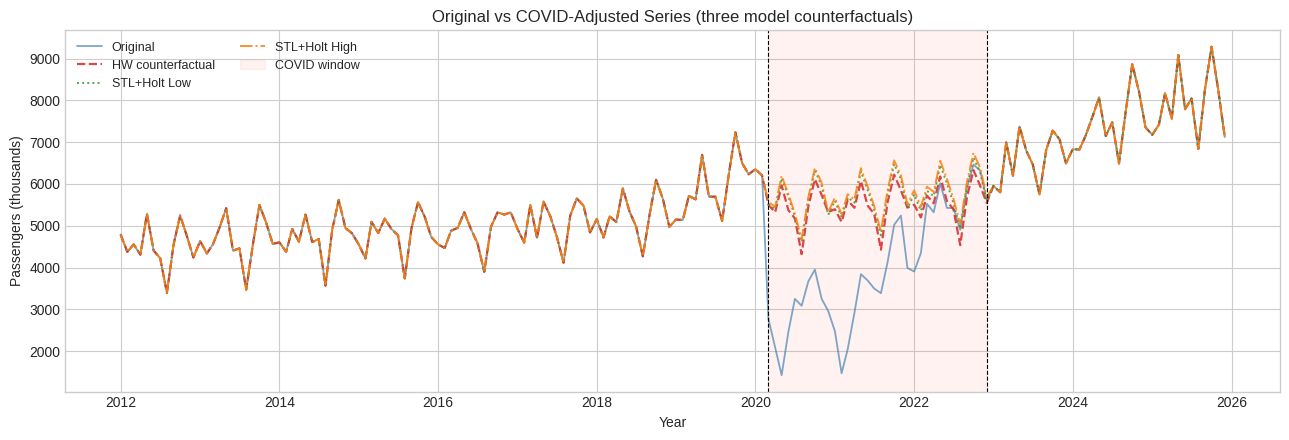

In [11]:
# Full-series plot: original vs all three COVID-adjusted series
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(series.index, series.values,
        color="steelblue", linewidth=1.3, alpha=0.7, label="Original")
ax.plot(series_hw.index, series_hw.values,
        color="#d62728", linewidth=1.6, linestyle="--", alpha=0.85, label="HW counterfactual")
ax.plot(series_stl_low.index, series_stl_low.values,
        color="#2ca02c", linewidth=1.4, linestyle=":",  alpha=0.85, label="STL+Holt Low")
ax.plot(series_stl_high.index, series_stl_high.values,
        color="#ff7f0e", linewidth=1.4, linestyle="-.", alpha=0.85, label="STL+Holt High")
ax.axvspan(COVID_START, COVID_END, color="tomato", alpha=0.08, label="COVID window")
ax.axvline(COVID_START, color="black", linestyle="--", linewidth=0.8)
ax.axvline(COVID_END,   color="black", linestyle="--", linewidth=0.8)
ax.set_title("Original vs COVID-Adjusted Series (three model counterfactuals)")
ax.set_xlabel("Year")
ax.set_ylabel("Passengers (thousands)")
ax.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig(fig_dir / "eda_covid_model_adjusted.png", dpi=300)
plt.show()


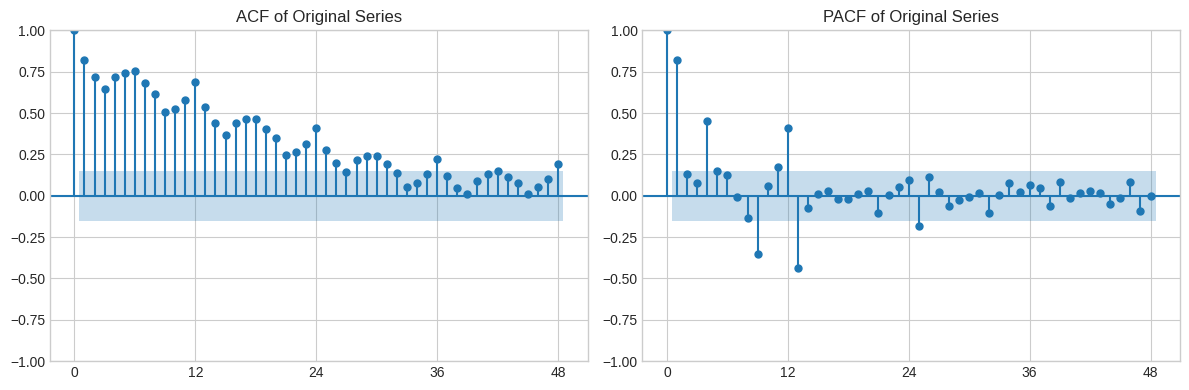

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot ACF and PACF
plot_acf(series_hw, lags=48, bartlett_confint=False, ax=axes[0])
axes[0].set_title('ACF of Original Series')

plot_pacf(series_hw, lags=48, method='ywm', ax=axes[1])
axes[1].set_title('PACF of Original Series')

# Set x-axis ticks every 12 lags for both plots
for ax in axes:
    ax.xaxis.set_major_locator(ticker.MultipleLocator(12))

plt.tight_layout()
plt.savefig(fig_dir / 'eda_acf_pacf_raw.png', dpi=300)
plt.show()

In [13]:
# train is always built from series_hw (COVID window replaced by HW counterfactual)
# series_hw is defined in EDA Section 3 (covid_adj_code cell).
# After the EDA chapter series_hw is the canonical series used for all model fitting.
train = series_hw.loc[:train_end]
valid = series.loc[val_start:val_end]   # validation always uses original observed values

assert len(valid) == 12, "Validation window must be exactly 12 months."
print(f"Train (series_hw): {train.index.min().date()} -> {train.index.max().date()} ({len(train)} obs)")
print(f"Validation (original): {valid.index.min().date()} -> {valid.index.max().date()} ({len(valid)} obs)")

Train (series_hw): 2012-01-01 -> 2024-12-01 (156 obs)
Validation (original): 2025-01-01 -> 2025-12-01 (12 obs)


## 4. Smoothing and Decomposition Methods

### 4.1 STL Decomposition



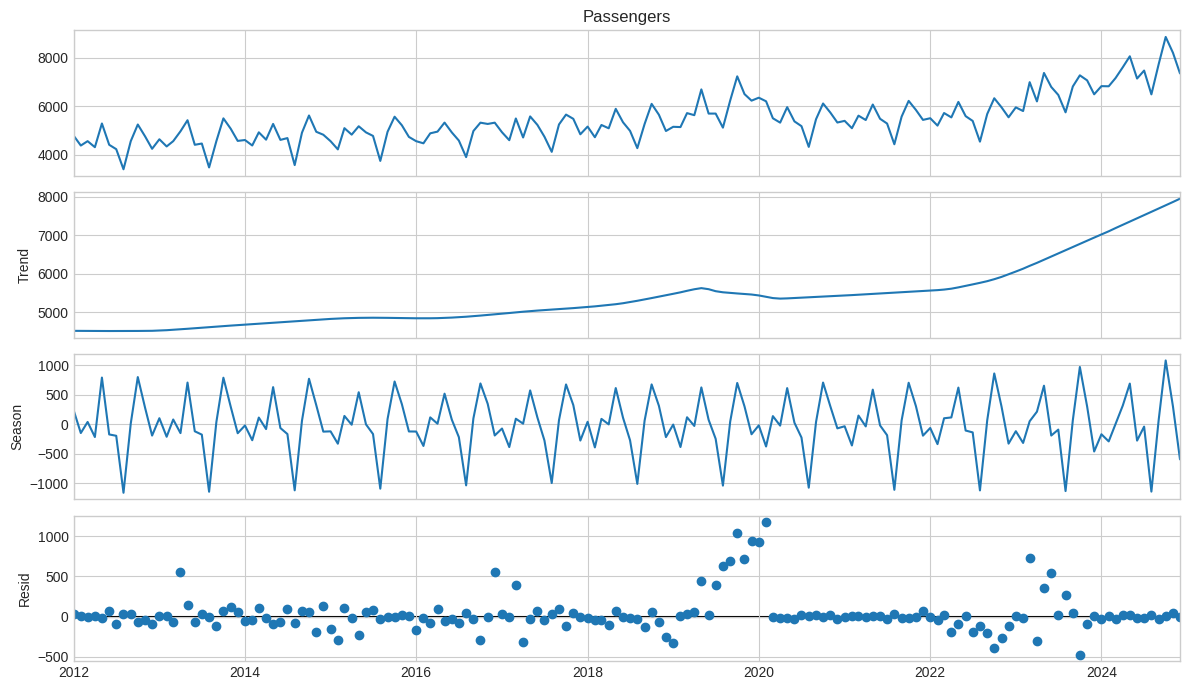

In [14]:
# train is series_hw-based (COVID-adjusted) — see train/valid split cell

stl = STL(train, period=SEASONAL_PERIOD, robust=True).fit()

fig = stl.plot()
fig.set_size_inches(12, 7)
plt.tight_layout()
plt.savefig(fig_dir / 'stl_decomposition_train.png', dpi=300)
plt.show()

stl_components = pd.DataFrame({
    'Observed': train,
    'Trend': stl.trend,
    'Seasonal': stl.seasonal,
    'Remainder': stl.resid,
    'Seasonally_Adjusted': train - stl.seasonal
})
stl_components.to_csv(tables_dir / 'stl_components_train.csv')


### 4.2 Decomposition-Based Forecast: STL + Holt



In [15]:
# train is series_hw-based (COVID-adjusted) — see train/valid split cell
# STL + ETS decomposition-based forecast
# Step 1: STL decomposition on training data (robust=True to down-weight COVID outliers)
stl_for_fc = STL(train, period=SEASONAL_PERIOD, robust=True).fit()
seasonal_component = stl_for_fc.seasonal           # shape: (len(train),)
sa_series = train - seasonal_component              # seasonally-adjusted

# Step 2: Fit simple exponential smoothing with trend (Holt, no seasonal) on SA series
from statsmodels.tsa.holtwinters import Holt
holt_sa = Holt(sa_series, damped_trend=False).fit(optimized=True)
sa_forecast = holt_sa.forecast(HORIZON)

# Step 3: Re-add seasonal factors — wrap-around from last 12 months of training
last_seasonal = seasonal_component.iloc[-SEASONAL_PERIOD:].values
stl_ets_pred = pd.Series(
    sa_forecast.values + last_seasonal,
    index=pd.date_range(start=f'{VALIDATION_YEAR}-01-01', periods=HORIZON, freq='MS')
)

print('STL+ETS Decomposition Forecast (2025 validation):')
print(pd.DataFrame({'Actual': valid.values, 'STL_ETS': stl_ets_pred.values}, index=valid.index).round(1))

# Interpret the seasonal component
print('\nSTL Seasonal Component Summary (by month):')
stl_seasonal_by_month = pd.DataFrame({
    'month': stl_for_fc.seasonal.index.month,
    'seasonal': stl_for_fc.seasonal.values
}).groupby('month')['seasonal'].mean()
stl_seasonal_by_month.index = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
print(stl_seasonal_by_month.round(1))
print(f'\nLargest negative seasonal factor: {stl_seasonal_by_month.idxmin()} ({stl_seasonal_by_month.min():.1f})')
print(f'Largest positive seasonal factor: {stl_seasonal_by_month.idxmax()} ({stl_seasonal_by_month.max():.1f})')
print(f'Seasonal std: {stl_for_fc.seasonal.std():.2f}  |  Remainder std: {stl_for_fc.resid.std():.2f}')
print('Note: remainder std ≈ seasonal std suggests the irregular component is as variable as seasonality.')


STL+ETS Decomposition Forecast (2025 validation):
            Actual  STL_ETS
Date                       
2025-01-01  7174.0   7827.1
2025-02-01  7421.0   7765.2
2025-03-01  8175.0   8116.0
2025-04-01  7565.0   8489.5
2025-05-01  9085.0   8921.0
2025-06-01  7788.0   8014.2
2025-07-01  8046.0   8310.1
2025-08-01  6840.0   7268.3
2025-09-01  8274.0   8538.0
2025-10-01  9284.0   9607.1
2025-11-01  8244.0   8886.2
2025-12-01  7123.0   8049.6

STL Seasonal Component Summary (by month):
Jan     -25.1
Feb    -318.3
Mar      97.3
Apr      11.6
May     630.0
Jun     -39.7
Jul    -181.6
Aug   -1087.2
Sep      62.4
Oct     782.5
Nov     313.3
Dec    -235.1
Name: seasonal, dtype: float64

Largest negative seasonal factor: Aug (-1087.2)
Largest positive seasonal factor: Oct (782.5)
Seasonal std: 466.25  |  Remainder std: 243.04
Note: remainder std ≈ seasonal std suggests the irregular component is as variable as seasonality.


In [16]:
# train = series_hw[:train_end]  (set in the train/valid split cell)
# HW_Mul uses train_stl_low to provide a second adjusted variant.

train_stl_low = series_stl_low.loc[:pd.Timestamp(f"{VALIDATION_YEAR-1}-12-01")]

# Baseline: seasonal naive from original observed train
seasonal_naive_pred = series.loc[:pd.Timestamp(f"{VALIDATION_YEAR-1}-12-01")].iloc[-SEASONAL_PERIOD:].values

# Holt-Winters additive -- train (series_hw based)
hw_add = ExponentialSmoothing(
    train, trend="add", seasonal="add", seasonal_periods=SEASONAL_PERIOD
).fit(optimized=True)
hw_add_pred = hw_add.forecast(HORIZON)

# Holt-Winters multiplicative -- STL+Holt Low-adjusted data
hw_mul = ExponentialSmoothing(
    train_stl_low, trend="add", seasonal="mul", seasonal_periods=SEASONAL_PERIOD
).fit(optimized=True)
hw_mul_pred = hw_mul.forecast(HORIZON)

# Damped-trend HW additive -- train (series_hw based)
hw_dmp = ExponentialSmoothing(
    train, trend="add", damped_trend=True, seasonal="add", seasonal_periods=SEASONAL_PERIOD
).fit(optimized=True)
hw_dmp_pred = hw_dmp.forecast(HORIZON)

print("Smoothing models fitted.")
print(f"  train (series_hw): {train.index.min().date()} -> {train.index.max().date()} ({len(train)} obs)")
print(f"  train_stl_low:     {train_stl_low.index.min().date()} -> {train_stl_low.index.max().date()} ({len(train_stl_low)} obs)")


Smoothing models fitted.
  train (series_hw): 2012-01-01 -> 2024-12-01 (156 obs)
  train_stl_low:     2012-01-01 -> 2024-12-01 (156 obs)


In [25]:
# Estimation results for smoothing methods (rubric requirement)



smoothing_estimation = pd.DataFrame([
    {
        'Model': 'HW_Add',
        'alpha_level': hw_add.params.get('smoothing_level', np.nan),
        'beta_trend': hw_add.params.get('smoothing_trend', np.nan),
        'gamma_seasonal': hw_add.params.get('smoothing_seasonal', np.nan),
        'phi_damping': np.nan,
        'Lt': hw_add.level.iloc[-1] if hasattr(hw_add.level, 'iloc') else hw_add.level[-1],
        'Tt': hw_add.trend.iloc[-1] if hw_add.trend is not None and hasattr(hw_add.trend, 'iloc') else (hw_add.trend[-1] if hw_add.trend is not None else 0.0),
        'SSE': hw_add.sse,
    },
    {
        'Model': 'HW_Mul',
        'alpha_level': hw_mul.params.get('smoothing_level', np.nan),
        'beta_trend': hw_mul.params.get('smoothing_trend', np.nan),
        'gamma_seasonal': hw_mul.params.get('smoothing_seasonal', np.nan),
        'phi_damping': np.nan,
        'Lt': hw_mul.level.iloc[-1] if hasattr(hw_add.level, 'iloc') else hw_add.level[-1],
        'Tt': hw_mul.trend.iloc[-1] if hw_add.trend is not None and hasattr(hw_add.trend, 'iloc') else (hw_add.trend[-1] if hw_add.trend is not None else 0.0),
        'SSE': hw_mul.sse,
    },
    {
        'Model': 'HW_Damp_Add',
        'alpha_level': hw_dmp.params.get('smoothing_level', np.nan),
        'beta_trend': hw_dmp.params.get('smoothing_trend', np.nan),
        'gamma_seasonal': hw_dmp.params.get('smoothing_seasonal', np.nan),
        'phi_damping': hw_dmp.params.get('damping_trend', np.nan),
        'Lt': hw_dmp.level.iloc[-1] if hasattr(hw_add.level, 'iloc') else hw_add.level[-1],
        'Tt': hw_dmp.trend.iloc[-1] if hw_add.trend is not None and hasattr(hw_add.trend, 'iloc') else (hw_add.trend[-1] if hw_add.trend is not None else 0.0),
        'SSE': hw_dmp.sse,
    },
])
smoothing_estimation.to_csv(tables_dir / 'smoothing_estimation_results.csv', index=False)
print(smoothing_estimation.to_string(index=False))

# --- Boundary solution commentary ---
print('\n--- Boundary Parameter Diagnostics ---')
for _, row in smoothing_estimation.iterrows():
    flags = []
    if abs(row['beta_trend']) < 1e-6:
        flags.append('β=0 (frozen trend: trend component never updated after initialisation)')
    if abs(row['gamma_seasonal']) < 1e-6:
        flags.append('γ=0 (frozen seasonality: seasonal factors set at init and never updated)')
    if abs(row['alpha_level'] - 1.0) < 1e-4:
        flags.append('α=1 (random-walk level: all weight on most recent observation, zero memory)')
    if flags:
        print(f"  {row['Model']}: " + '; '.join(flags))
    else:
        print(f"  {row['Model']}: no boundary solutions detected")

print("""
NOTE: β=0 and γ=0 are boundary/corner solutions from the parameter optimiser.
They indicate the model cannot simultaneously adapt to the COVID disruption and
the post-recovery growth. With frozen trend and frozen seasonality, HW_Add and
HW_Mul are simpler models than their specification implies. For HW_Mul, α=1.0
means the level is always the most recent observation (random-walk level).
Prediction intervals from these models may be unreliable due to misspecification.
HW_Damp_Add is included as an alternative that constrains trend growth via φ.
""")


      Model  alpha_level  beta_trend  gamma_seasonal  phi_damping          Lt        Tt          SSE
     HW_Add     0.560609         0.0             0.0          NaN 7679.901783 19.270686 7.712260e+06
     HW_Mul     0.458210         0.0             0.0          NaN 7442.050654 19.769487 8.406752e+06
HW_Damp_Add     0.564820         0.0             0.0        0.995 7690.461972 10.612745 7.817720e+06

--- Boundary Parameter Diagnostics ---
  HW_Add: β=0 (frozen trend: trend component never updated after initialisation); γ=0 (frozen seasonality: seasonal factors set at init and never updated)
  HW_Mul: β=0 (frozen trend: trend component never updated after initialisation); γ=0 (frozen seasonality: seasonal factors set at init and never updated)
  HW_Damp_Add: β=0 (frozen trend: trend component never updated after initialisation); γ=0 (frozen seasonality: seasonal factors set at init and never updated)

NOTE: β=0 and γ=0 are boundary/corner solutions from the parameter optimiser.
They in

In [21]:
models_info = {
    'HW_Add':      (hw_add, train),
    'HW_Mul':      (hw_mul, train_stl_low),  # usa a sua própria série de treino
    'HW_Damp_Add': (hw_dmp, train),
}

mape_dict = {}
rmse_dict = {}

for name, (model, series_train) in models_info.items():
    mape, rmse = calcular_metricas(series_train.values, model.fittedvalues.values)
    mape_dict[name] = mape
    rmse_dict[name] = rmse

# Adicionar ao DataFrame
smoothing_estimation['MAPE'] = smoothing_estimation['Model'].map(mape_dict)
smoothing_estimation['RMSE'] = smoothing_estimation['Model'].map(rmse_dict)

smoothing_estimation.to_csv(tables_dir / 'smoothing_estimation_results.csv', index=False)
print(smoothing_estimation.to_string(index=False))

      Model  alpha_level  beta_trend  gamma_seasonal  phi_damping          SSE     MAPE       RMSE
     HW_Add     0.560609         0.0             0.0          NaN 7.712260e+06 2.845648 222.345598
     HW_Mul     0.458210         0.0             0.0          NaN 8.406752e+06 3.214604 232.140982
HW_Damp_Add     0.564820         0.0             0.0        0.995 7.817720e+06 2.861605 223.860650


## 5. SARIMA Model Development

### 5.1 SARIMA — Methodology and Identification



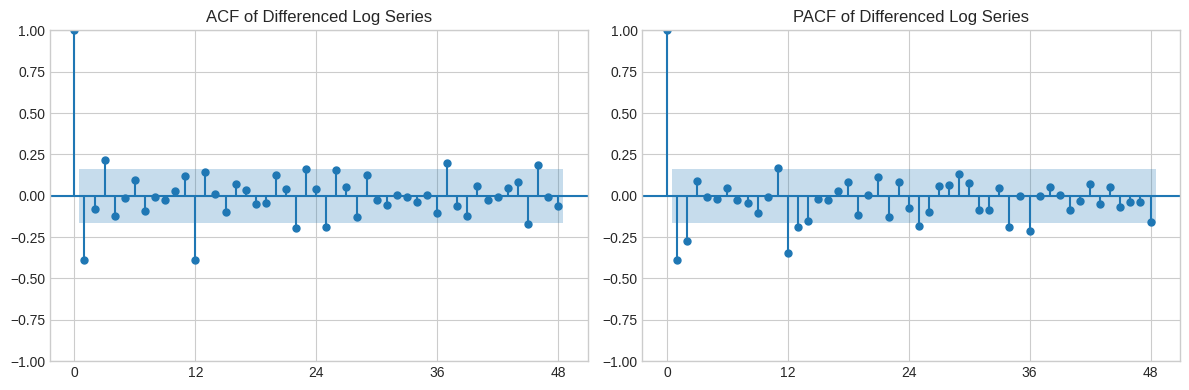

In [33]:
# Transformation and differencing discussion support
train_log = np.log(train)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(train_log.diff().dropna().diff(12).dropna(), lags=48, bartlett_confint=False, ax=axes[0])
axes[0].set_title('ACF of Differenced Log Series')

plot_pacf(train_log.diff().dropna().diff(12).dropna(), lags=48, method='ywm', ax=axes[1])
axes[1].set_title('PACF of Differenced Log Series')

# Set x-axis ticks every 12 lags for both plots
for ax in axes:
    ax.xaxis.set_major_locator(ticker.MultipleLocator(12))

plt.tight_layout()
plt.savefig(fig_dir / 'sarima_identification_acf_pacf.png', dpi=300)
plt.show()

In [46]:
# Shortlist: original SMA-only models + P>0 candidates to test seasonal AR structure
sarima_shortlist = {
    'SARIMA_011_011': ((0, 1, 1), (0, 1, 1, 12)),
    'SARIMA_111_011': ((1, 1, 1), (0, 1, 1, 12)),   # SMA(2) to test richer seasonal MA structure
    'SARIMA_310_011': ((3, 1, 0), (0, 1, 1, 12)),
    'SARIMA_011_110': ((0, 1, 1), (1, 1, 0, 12)),   # SAR(1) alternative
    'SARIMA_111_111': ((1, 1, 1), (1, 1, 1, 12)),   # mixed seasonal structure
    'SARIMA_310_110': ((3, 1, 0), (1, 1, 0, 12)),
    'SARIMA_311_110': ((3, 1, 1), (1, 1, 0, 12)),
}

sarima_results = []
sarima_validation_forecasts = {}

def aicc(aic, k, n):
    """AICc small-sample correction."""
    if n - k - 1 <= 0:
        return np.nan
    return aic + (2 * k * (k + 1)) / (n - k - 1)

for name, (order, seasonal_order) in sarima_shortlist.items():
    try:
        model = SARIMAX(
            train_log,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False,
        )
        fit = model.fit(disp=False)

        resid = fit.resid.dropna()
        model_df = order[0] + order[2] + seasonal_order[0] + seasonal_order[2]
        lb = acorr_ljungbox(resid, lags=[12, 24], model_df=model_df, return_df=True)

        fc = fit.get_forecast(steps=HORIZON)
        mean_fc = np.exp(fc.predicted_mean)
        ci = fc.conf_int(alpha=0.05)
        lo = np.exp(ci.iloc[:, 0])
        hi = np.exp(ci.iloc[:, 1])

        sarima_validation_forecasts[name] = {
            'fit': fit,
            'mean': mean_fc,
            'low': lo,
            'high': hi,
        }

        n_obs = len(train_log)
        k_params = fit.df_model
        sarima_results.append({
            'Model': name,
            'Order': str(order),
            'Seasonal_Order': str(seasonal_order),
            'AIC': fit.aic,
            'AICc': aicc(fit.aic, k_params, n_obs),
            'BIC': fit.bic,
            'LjungBox_p_12': lb.loc[12, 'lb_pvalue'] if 12 in lb.index else np.nan,
            'LjungBox_p_24': lb.loc[24, 'lb_pvalue'] if 24 in lb.index else np.nan,
        })
    except Exception as e:
        print(e)
        sarima_results.append({
            'Model': name,
            'Order': str(order),
            'Seasonal_Order': str(seasonal_order),
            'AIC': np.nan,
            'AICc': np.nan,
            'BIC': np.nan,
            'LjungBox_p_12': np.nan,
            'LjungBox_p_24': np.nan,
        })

sarima_table = pd.DataFrame(sarima_results).sort_values('AIC')
sarima_table.to_csv(tables_dir / 'sarima_shortlist_aic_bic.csv', index=False)
sarima_table



,Model,Order,Seasonal_Order,AIC,AICc,BIC,LjungBox_p_12,LjungBox_p_24
2,SARIMA_310_011,"(3, 1, 0)","(0, 1, 1, 12)",-417.758166,-417.358166,-403.420494,7.571729e-07,0.000696
0,SARIMA_011_011,"(0, 1, 1)","(0, 1, 1, 12)",-414.368195,-414.210300,-405.788757,1.202752e-04,0.037349
1,SARIMA_111_011,"(1, 1, 1)","(0, 1, 1, 12)",-412.628956,-412.364055,-401.189706,5.322689e-05,0.025554
4,SARIMA_111_111,"(1, 1, 1)","(1, 1, 1, 12)",-406.001816,-405.601816,-391.702754,4.345623e-05,0.025711
3,SARIMA_011_110,"(0, 1, 1)","(1, 1, 0, 12)",-404.352285,-404.194390,-395.726693,1.242079e-02,0.383292
5,SARIMA_310_110,"(3, 1, 0)","(1, 1, 0, 12)",-398.087443,-397.687443,-383.827291,1.773799e-03,0.032221
6,SARIMA_311_110,"(3, 1, 1)","(1, 1, 0, 12)",-396.092332,-395.528574,-378.980150,1.315162e-03,0.033298


In [35]:
# Model coefficients for best-AIC SARIMA model
best_sarima_name = sarima_table.iloc[0]['Model']
best_fit = sarima_validation_forecasts[best_sarima_name]['fit']

# Save coefficient table
coef_df = pd.DataFrame({
    'coef':      best_fit.params,
    'std_err':   best_fit.bse,
    't_stat':    best_fit.tvalues,
    'p_value':   best_fit.pvalues,
    'ci_lower':  best_fit.conf_int().iloc[:, 0],
    'ci_upper':  best_fit.conf_int().iloc[:, 1],
})
coef_df.to_csv(tables_dir / 'sarima_best_coefficients.csv')
display(coef_df.round(4))


,coef,std_err,t_stat,p_value,ci_lower,ci_upper
ar.L1,-0.4978,0.0639,-7.7887,0.0000,-0.6230,-0.3725
ar.L2,-0.2636,0.0748,-3.5237,0.0004,-0.4103,-0.1170
ar.L3,0.1196,0.0888,1.3473,0.1779,-0.0544,0.2937
ma.S.L12,-0.7284,0.1138,-6.4010,0.0000,-0.9514,-0.5053
sigma2,0.0021,0.0002,11.8542,0.0000,0.0018,0.0024


In [ ]:
# --- Ajuste do SARIMAX na escala LOGARÍTMICA ---
exog_train_int = pd.Series(0, index=train_log.index, name='COVID_Shock')
exog_train_int.loc['2020-03':'2022-12'] = 1

model_intervention_log = SARIMAX(
    train_log,  # <--- CORRIGIDO: Agora usamos a escala logarítmica
    exog=exog_train_int,
    order=(3, 1, 0),
    seasonal_order=(0, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
results_final_train_log = model_intervention_log.fit(disp=False)

# --- Extração das Métricas para a Comparação Justa ---
model_df_sarimax = 3 + 0 + 0 + 1
resid_sarimax_log = results_final_train_log.resid.dropna()

# Ljung-Box na escala log
lb12_sx_log = acorr_ljungbox(resid_sarimax_log, lags=[12], model_df=model_df_sarimax, return_df=True)
p_12_sx_log = lb12_sx_log.loc[12, 'lb_pvalue']

lb24_sx_log = acorr_ljungbox(resid_sarimax_log, lags=[24], model_df=model_df_sarimax, return_df=True)
p_24_sx_log = lb24_sx_log.loc[24, 'lb_pvalue']

n_obs_sx = len(train_log)
k_params_sx = results_final_train_log.df_model

# Nova linha para a tua tabela comparativa
sarimax_log_metrics = pd.DataFrame([{
    'Model': 'SARIMAX_310_011_COVID_Log',
    'Order': '(3, 1, 0)',
    'Seasonal_Order': '(0, 1, 1, 12)',
    'AIC': results_final_train_log.aic,
    'AICc': aicc(results_final_train_log.aic, k_params_sx, n_obs_sx),
    'BIC': results_final_train_log.bic,
    'LjungBox_p_12': p_12_sx_log,
    'LjungBox_p_24': p_24_sx_log
}])

# Se quiseres ver a tabela antiga e a nova juntas e ordenadas pelo melhor AIC:
# sarima_table_completa = pd.concat([sarima_table, sarimax_log_metrics]).sort_values('AIC')
sarimax_log_metrics

,Model,Order,Seasonal_Order,AIC,AICc,BIC,LjungBox_p_12,LjungBox_p_24
0,SARIMAX_310_011_COVID_Log,"(3, 1, 0)","(0, 1, 1, 12)",-467.708606,-467.308606,-453.370933,5.383608e-08,0.00005


In [42]:
# Extrai apenas a tabela de coeficientes, erros padrão, p-values e intervalos de confiança
results_final_train.summary().tables[1]

,coef,std err,z,P>|z|,[0.025,0.975]
COVID_Shock,-922.2110,57.016,-16.175,0.000,-1033.960,-810.462
ar.L1,-0.6141,0.094,-6.537,0.000,-0.798,-0.430
ar.L2,-0.4217,0.079,-5.349,0.000,-0.576,-0.267
ar.L3,0.1265,0.074,1.715,0.086,-0.018,0.271
ma.S.L12,-1.0000,0.107,-9.314,0.000,-1.210,-0.790
sigma2,3.392e+04,6.12e-05,5.54e+08,0.000,3.39e+04,3.39e+04


### 5.3 SARIMA — Residual Diagnostics and Ljung-Box Assessment



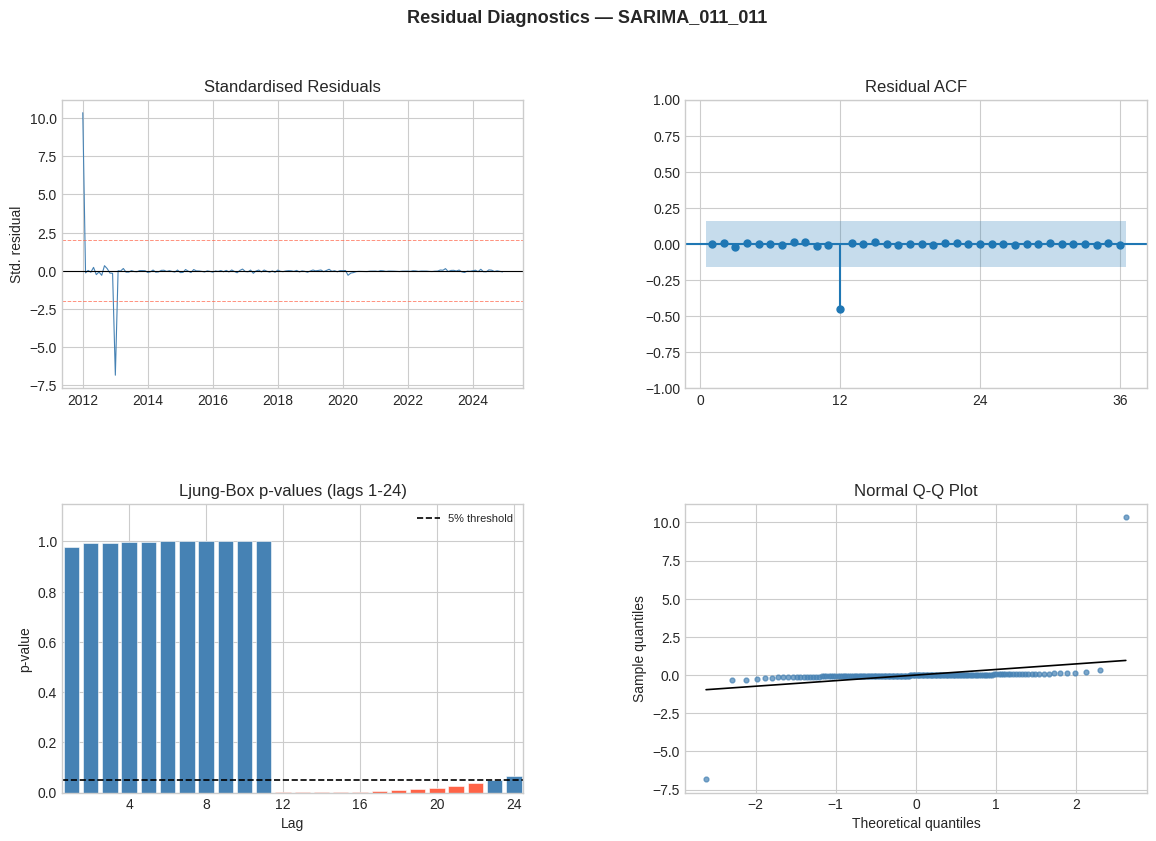

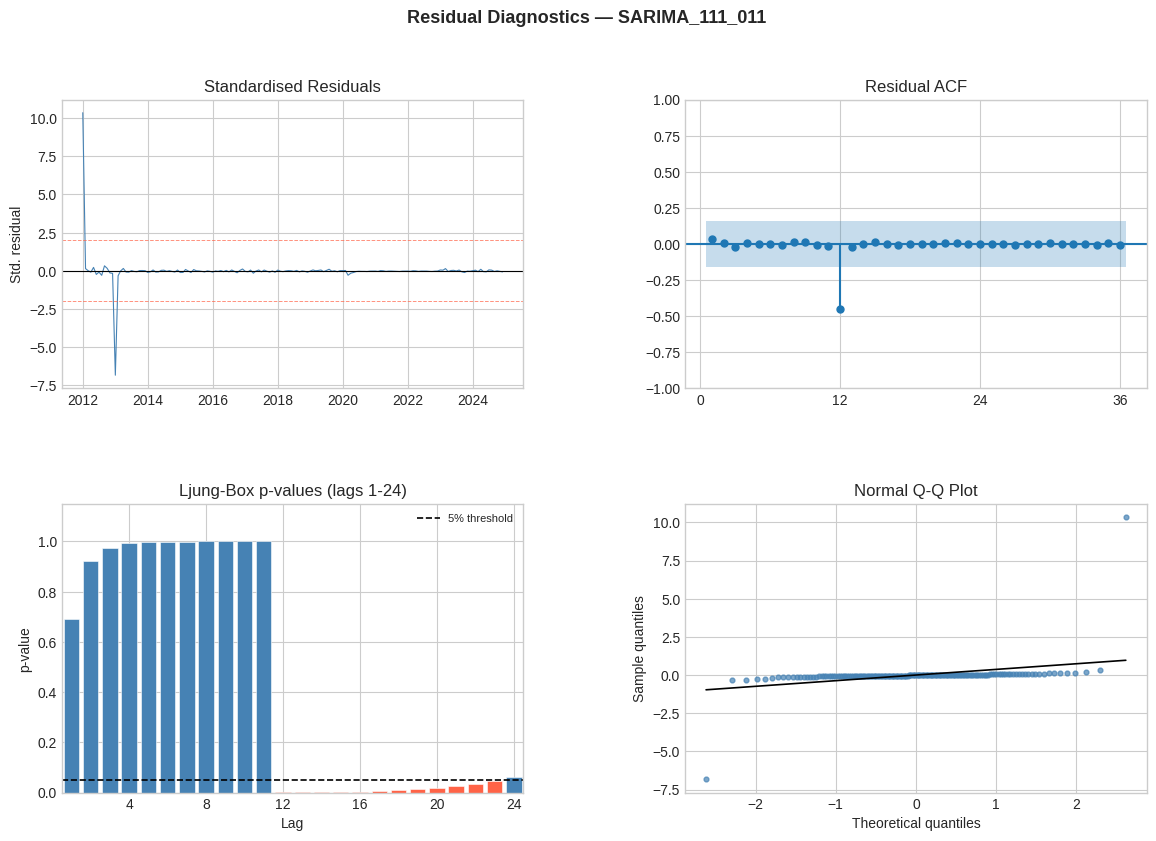

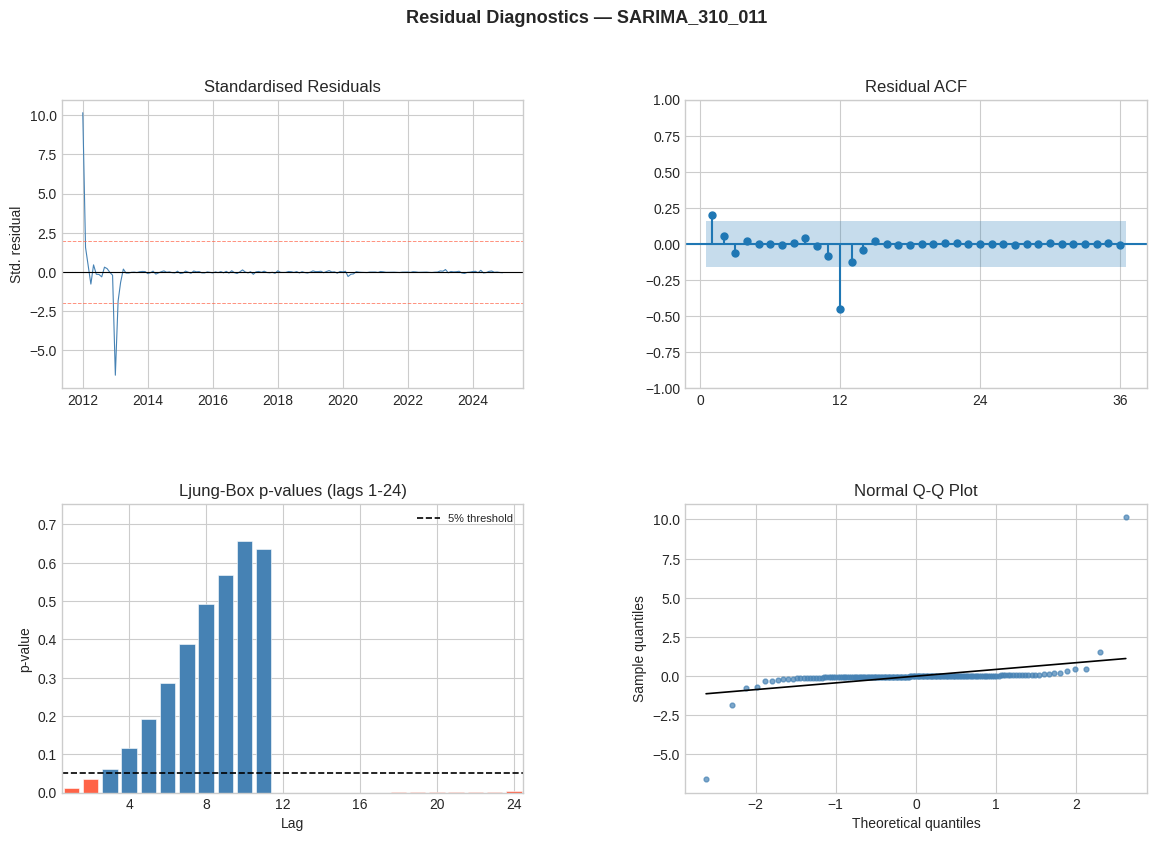

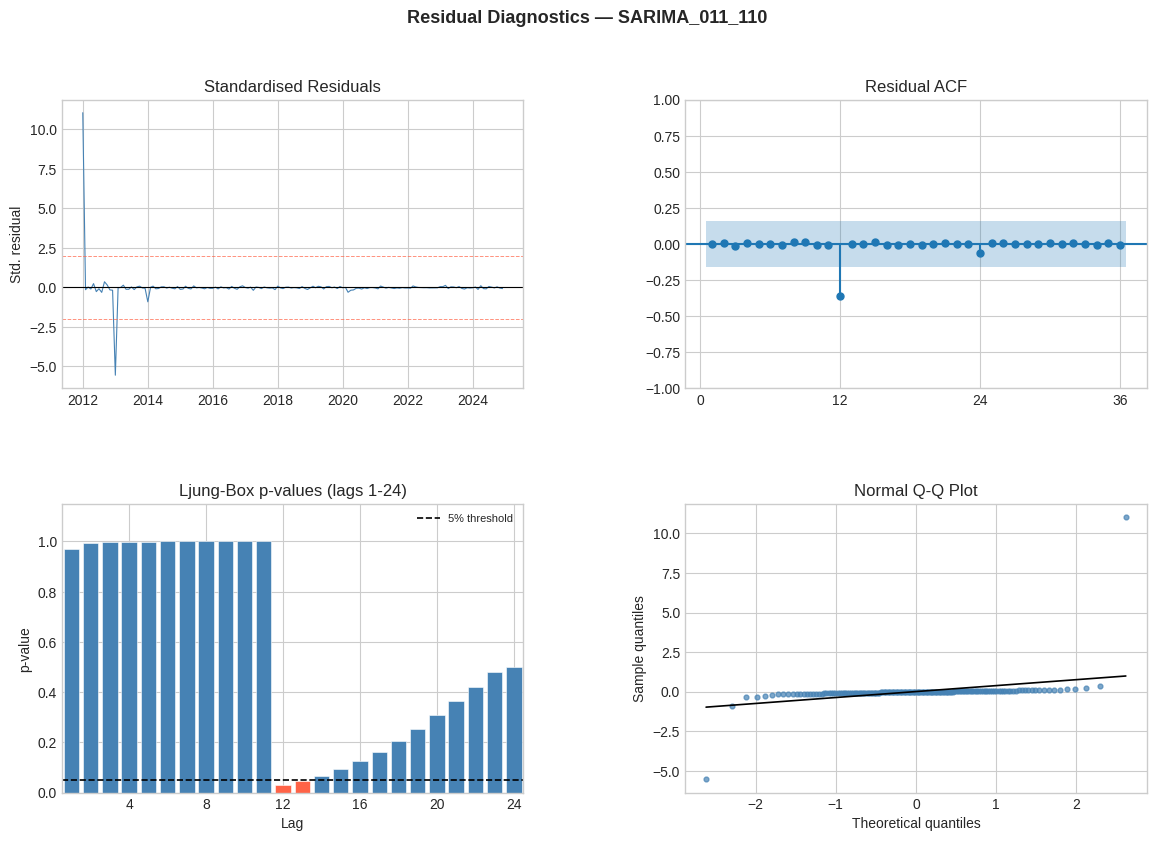

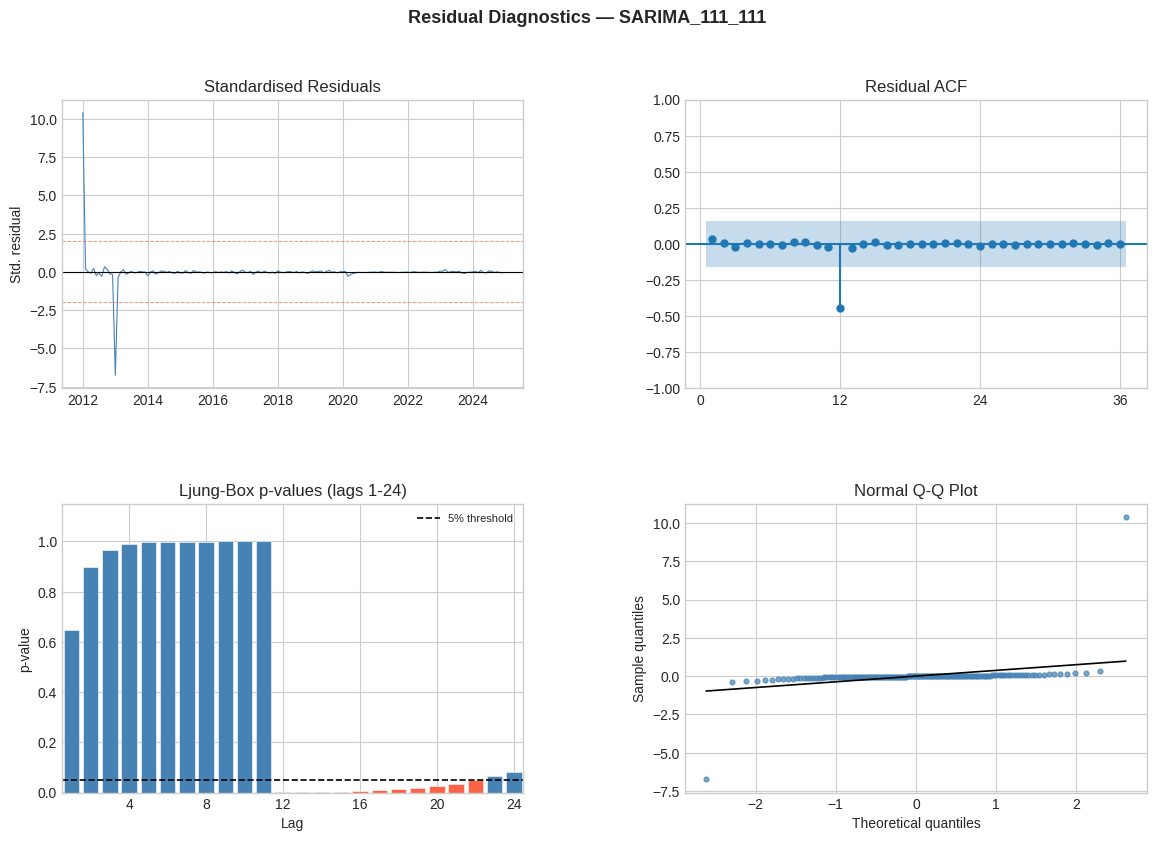

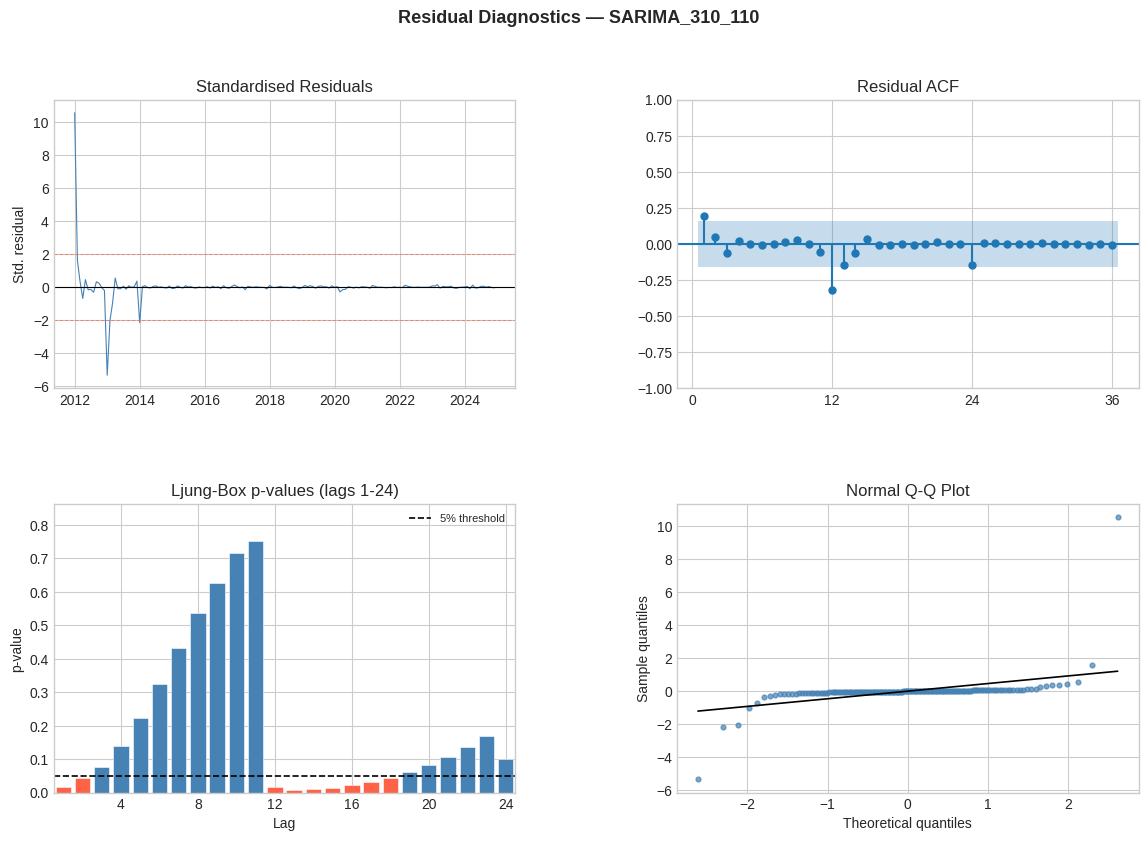

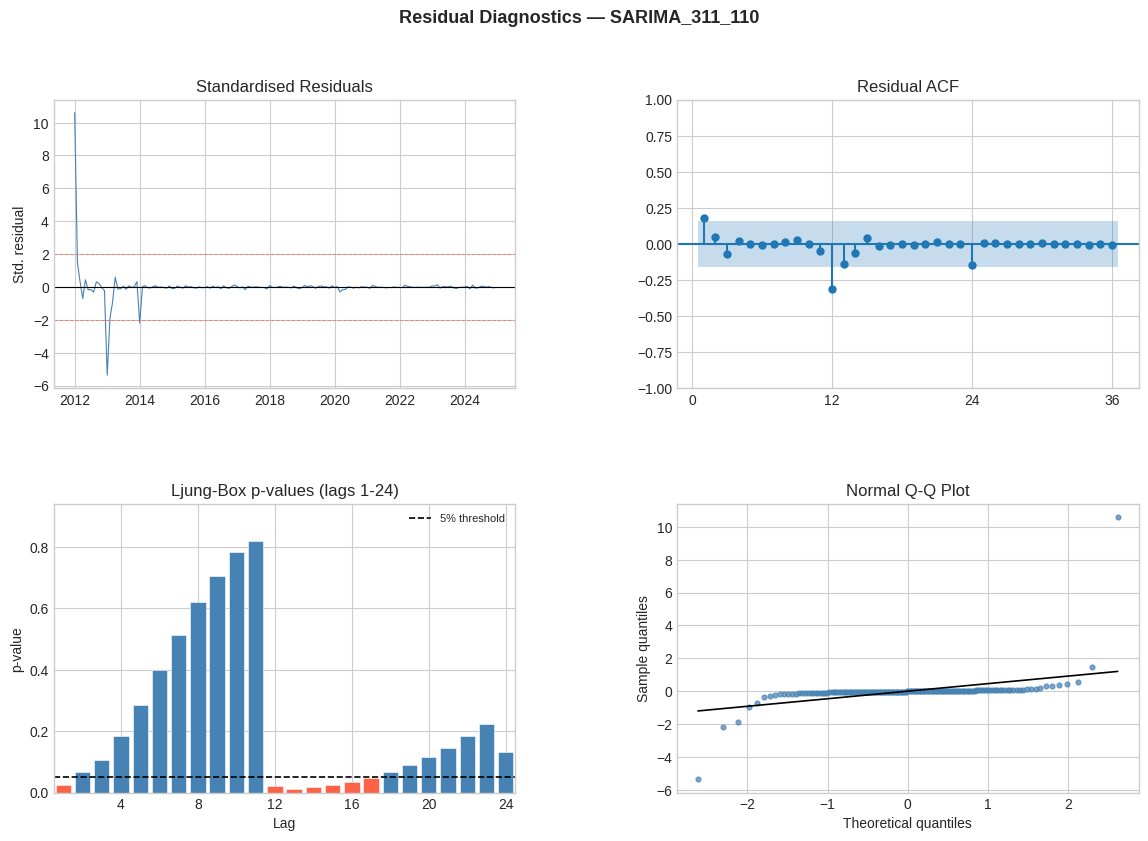

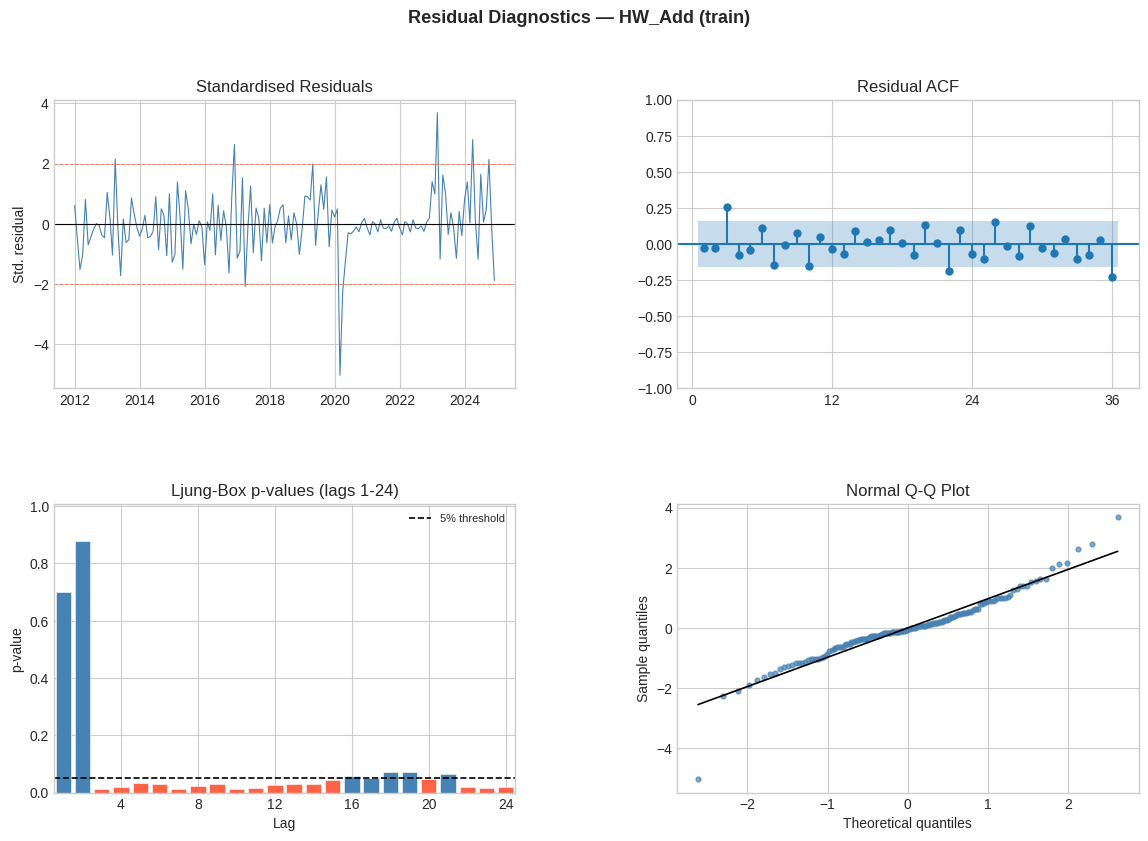

In [36]:
def plot_residual_diagnostics(resid, model_name, save_path):
    """Four-panel residual diagnostic plot: residuals, ACF, Ljung-Box p-values, Q-Q."""
    resid = resid.dropna()
    std_resid = (resid - resid.mean()) / resid.std()

    fig = plt.figure(figsize=(14, 9))
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

    # 1. Standardised residual time plot
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(resid.index if hasattr(resid, 'index') else range(len(resid)),
             std_resid, color='steelblue', linewidth=0.8)
    ax1.axhline(0, color='black', linewidth=0.8)
    ax1.axhline(2, color='tomato', linestyle='--', linewidth=0.7, alpha=0.7)
    ax1.axhline(-2, color='tomato', linestyle='--', linewidth=0.7, alpha=0.7)
    ax1.set_title('Standardised Residuals')
    ax1.set_ylabel('Std. residual')

    # 2. Residual ACF
    ax2 = fig.add_subplot(gs[0, 1])
    plot_acf(resid, lags=36, ax=ax2, zero=False, bartlett_confint=False)
    ax2.xaxis.set_major_locator(ticker.MultipleLocator(12))
    ax2.set_title('Residual ACF')

    # 3. Ljung-Box p-values (lags 1-24)
    ax3 = fig.add_subplot(gs[1, 0])
    lb_lags = list(range(1, 25))
    lb_result = acorr_ljungbox(resid, lags=lb_lags, return_df=True)
    lb_pvals = lb_result['lb_pvalue'].values
    colors = ['tomato' if p < 0.05 else 'steelblue' for p in lb_pvals]
    ax3.bar(lb_lags, lb_pvals, color=colors, edgecolor='white', linewidth=0.4)
    ax3.axhline(0.05, color='black', linestyle='--', linewidth=1.2, label='5% threshold')
    ax3.set_xlim(0.5, 24.5)
    ax3.set_ylim(0, max(0.12, lb_pvals.max() * 1.15))
    ax3.xaxis.set_major_locator(ticker.MultipleLocator(4))
    ax3.set_title('Ljung-Box p-values (lags 1-24)')
    ax3.set_xlabel('Lag')
    ax3.set_ylabel('p-value')
    ax3.legend(fontsize=8)

    # 4. Q-Q plot
    ax4 = fig.add_subplot(gs[1, 1])
    (osm, osr), (slope, intercept, _) = stats.probplot(std_resid, dist='norm')
    ax4.scatter(osm, osr, s=12, color='steelblue', alpha=0.7)
    ax4.plot(osm, slope * np.array(osm) + intercept, color='black', linewidth=1.2)
    ax4.set_title('Normal Q-Q Plot')
    ax4.set_xlabel('Theoretical quantiles')
    ax4.set_ylabel('Sample quantiles')

    fig.suptitle(f'Residual Diagnostics — {model_name}', fontsize=13, fontweight='bold')
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()


# Diagnostics for each SARIMA candidate
for name in sarima_shortlist:
    if name in sarima_validation_forecasts:
        fit = sarima_validation_forecasts[name]['fit']
        resid = fit.resid
        save_path = diagnostics_dir / f'residuals_{name}.png'
        plot_residual_diagnostics(resid, name, save_path)

# Diagnostics for selected HW model (training residuals)
hw_add_resid = pd.Series(hw_add.resid, index=train.index)
plot_residual_diagnostics(hw_add_resid, 'HW_Add (train)', diagnostics_dir / 'residuals_HW_Add_train.png')


In [47]:
def plot_residual_diagnostics(resid, model_name, save_path, model_df=0, burn_in=12):
    """
    Four-panel residual diagnostic plot: residuals, ACF, Ljung-Box p-values, Q-Q.
    
    Parameters:
    -----------
    model_df : int
        Número de parâmetros do modelo (p + q + P + Q) para corrigir o Ljung-Box.
    burn_in : int
        Número de observações iniciais a descartar para ignorar a inicialização difusa.
    """
    resid = resid.dropna()
    
    # 1. Cortar o início da série (burn-in) para remover o efeito de inicialização difusa
    if len(resid) > burn_in:
        resid_clean = resid.iloc[burn_in:]
    else:
        resid_clean = resid

    # Normalizar os resíduos usando apenas a amostra limpa
    std_resid = (resid_clean - resid_clean.mean()) / resid_clean.std()

    fig = plt.figure(figsize=(14, 9))
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

    # 1. Standardised residual time plot (mostra a série limpa)
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(resid_clean.index if hasattr(resid_clean, 'index') else range(len(resid_clean)),
             std_resid, color='steelblue', linewidth=0.8)
    ax1.axhline(0, color='black', linewidth=0.8)
    ax1.axhline(2, color='tomato', linestyle='--', linewidth=0.7, alpha=0.7)
    ax1.axhline(-2, color='tomato', linestyle='--', linewidth=0.7, alpha=0.7)
    ax1.set_title('Standardised Residuals (Excl. Burn-in)')
    ax1.set_ylabel('Std. residual')

    # 2. Residual ACF
    ax2 = fig.add_subplot(gs[0, 1])
    plot_acf(resid_clean, lags=36, ax=ax2, zero=False, bartlett_confint=False)
    ax2.xaxis.set_major_locator(ticker.MultipleLocator(12))
    ax2.set_title('Residual ACF')

    # 3. Ljung-Box p-values (lags 1-24) com correção de graus de liberdade
    ax3 = fig.add_subplot(gs[1, 0])
    lb_lags = list(range(1, 25))
    
    # IMPORTANTE: Passamos o model_df para o teste ser estatisticamente honesto
    lb_result = acorr_ljungbox(resid_clean, lags=lb_lags, model_df=model_df, return_df=True)
    lb_pvals = lb_result['lb_pvalue'].values
    
    # Criar vetor de lags correspondente (o statsmodels pode retornar NaN para lags <= model_df)
    colors = ['tomato' if (not np.isnan(p) and p < 0.05) else 'steelblue' for p in lb_pvals]
    
    # Substituir eventuais NaNs por 0 para o gráfico conseguir desenhar sem quebrar
    lb_pvals_plot = np.nan_to_num(lb_pvals, nan=0.0)
    
    ax3.bar(lb_lags, lb_pvals_plot, color=colors, edgecolor='white', linewidth=0.4)
    ax3.axhline(0.05, color='black', linestyle='--', linewidth=1.2, label='5% threshold')
    ax3.set_xlim(0.5, 24.5)
    
    # Define um teto dinâmico para o eixo Y
    ax3.set_ylim(0, max(1.05, lb_pvals_plot.max() * 1.15) if lb_pvals_plot.max() > 0 else 1.05)
    ax3.xaxis.set_major_locator(ticker.MultipleLocator(4))
    ax3.set_title('Ljung-Box p-values (lags 1-24)')
    ax3.set_xlabel('Lag')
    ax3.set_ylabel('p-value')
    ax3.legend(fontsize=8)

    # 4. Q-Q plot (Agora vai ficar perfeitamente linear sem os outliers de 2012)
    ax4 = fig.add_subplot(gs[1, 1])
    (osm, osr), (slope, intercept, _) = stats.probplot(std_resid, dist='norm')
    ax4.scatter(osm, osr, s=12, color='steelblue', alpha=0.7)
    ax4.plot(osm, slope * np.array(osm) + intercept, color='black', linewidth=1.2)
    ax4.set_title('Normal Q-Q Plot')
    ax4.set_xlabel('Theoretical quantiles')
    ax4.set_ylabel('Sample quantiles')

    fig.suptitle(f'Residual Diagnostics — {model_name}', fontsize=13, fontweight='bold')
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()

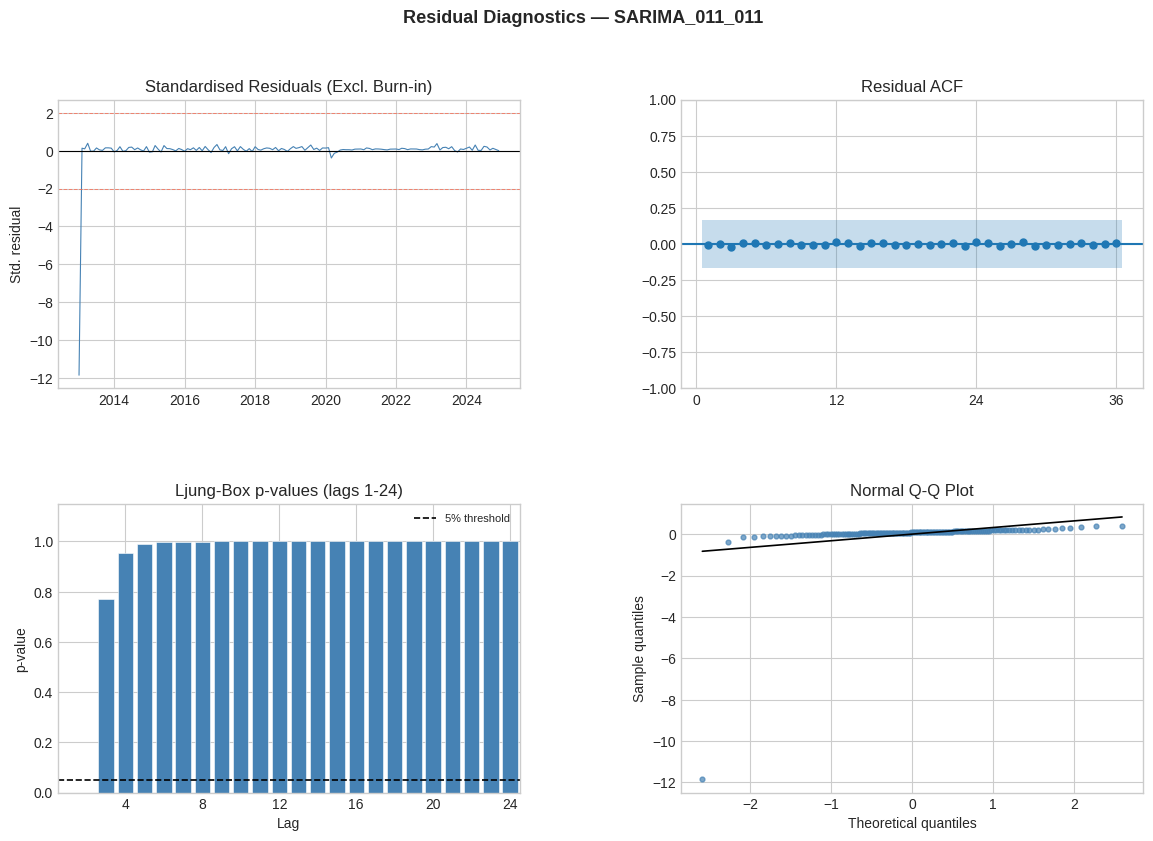

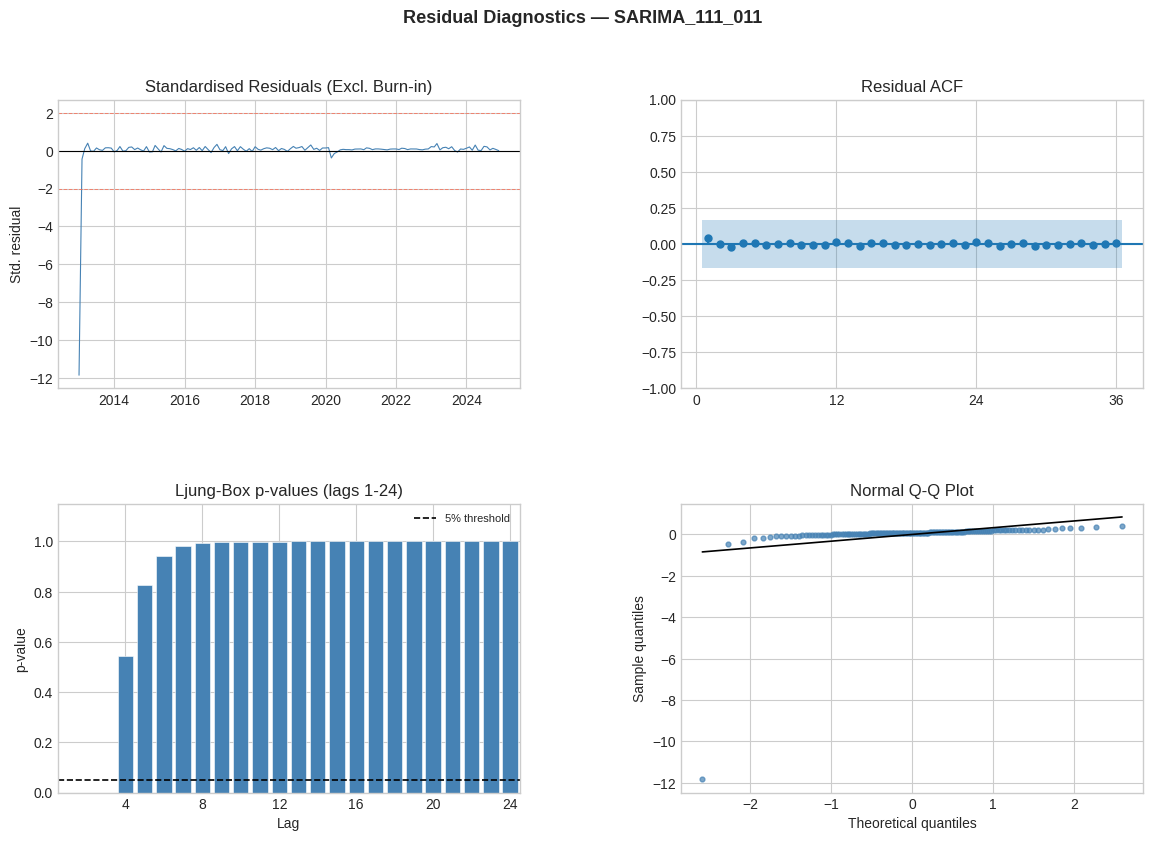

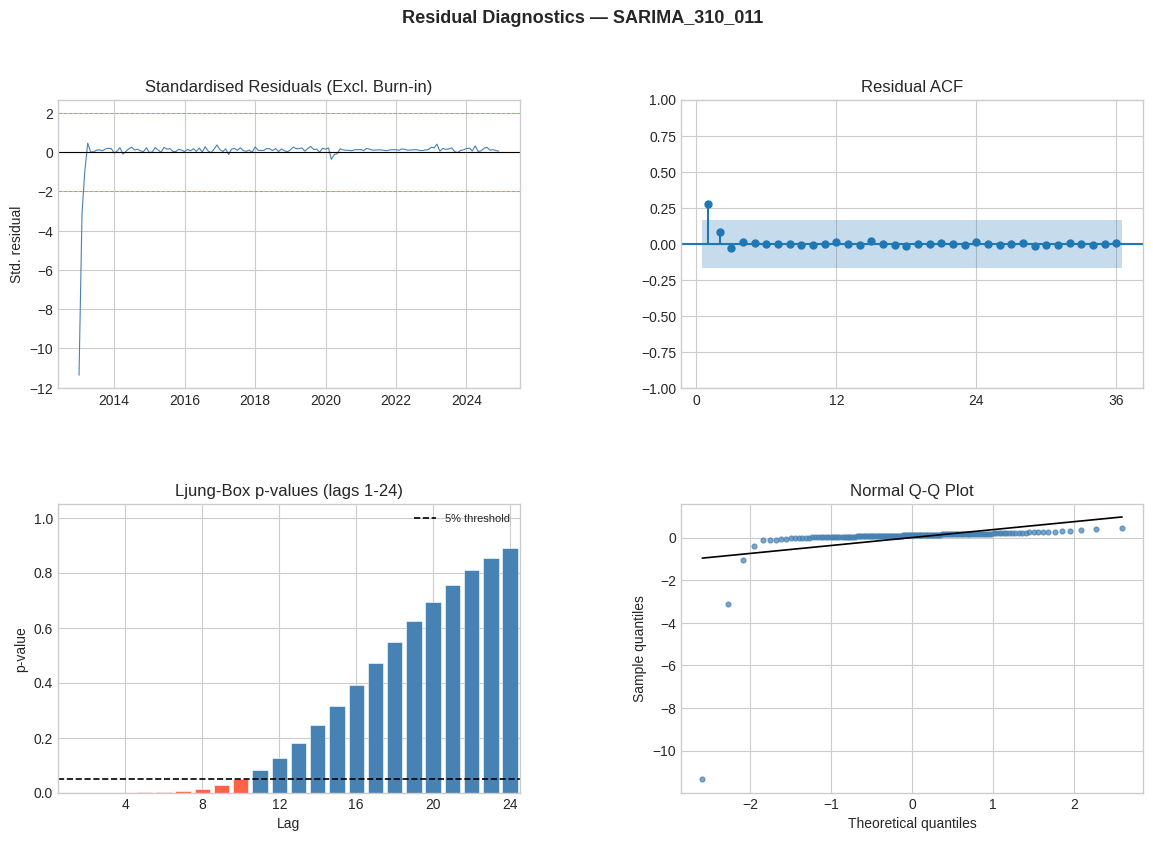

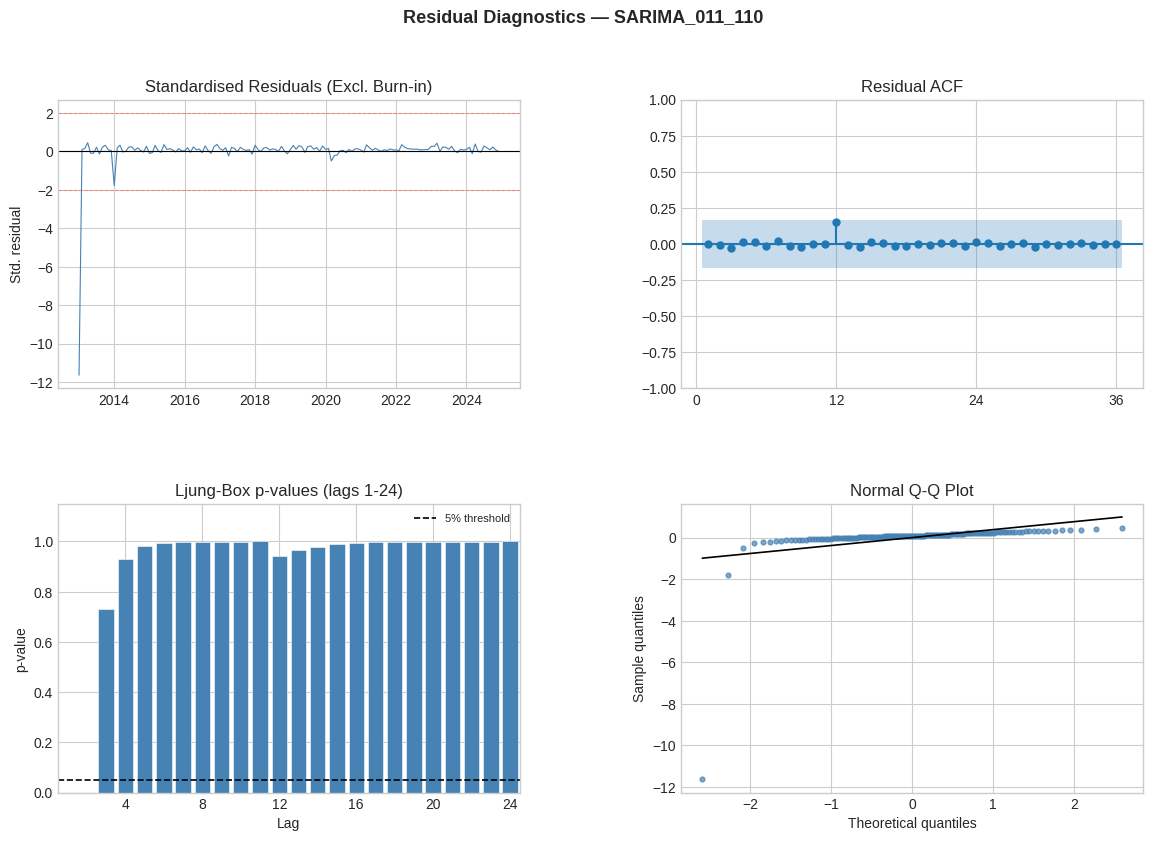

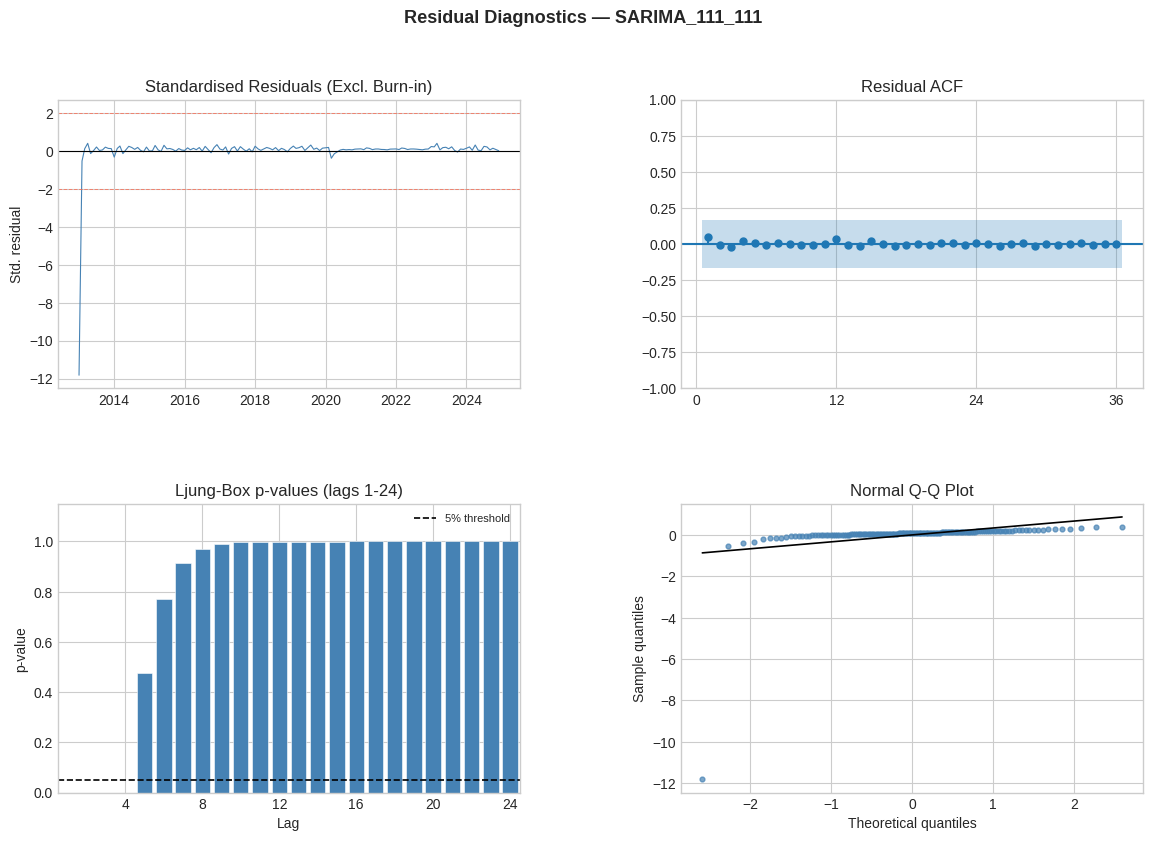

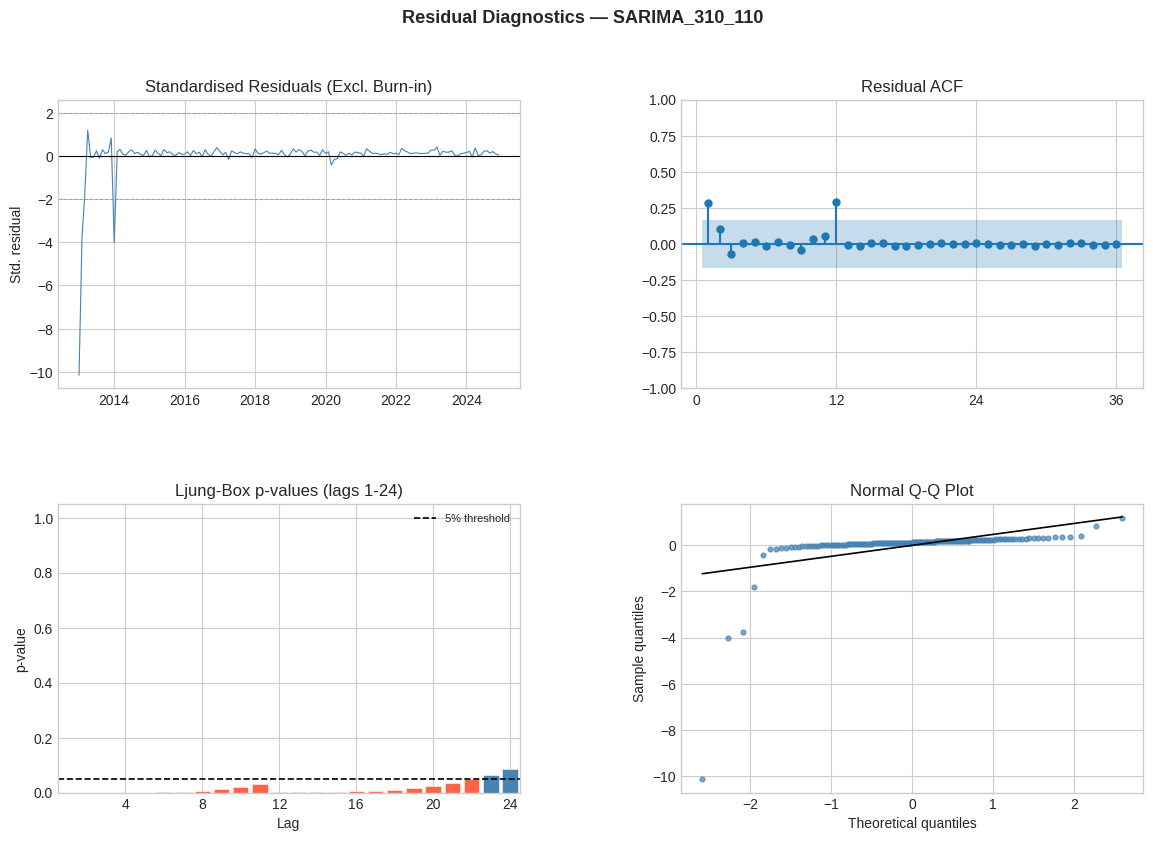

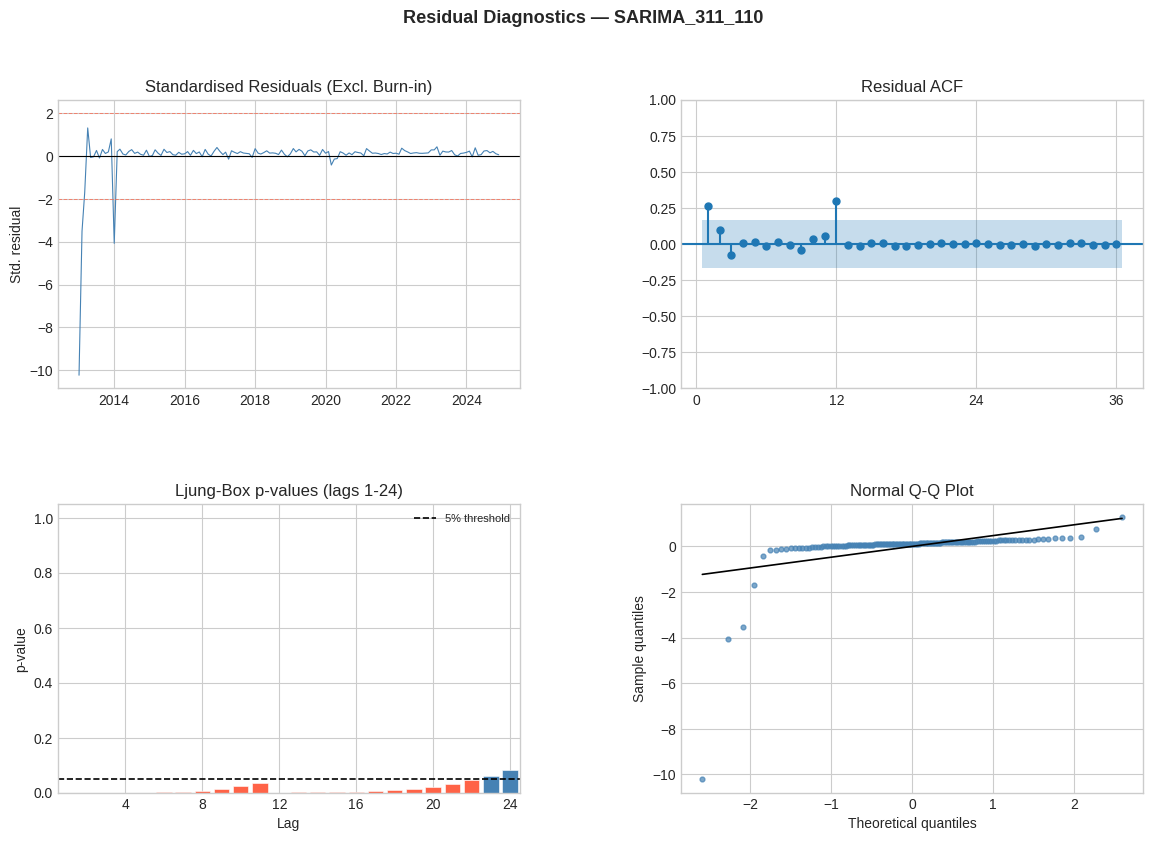

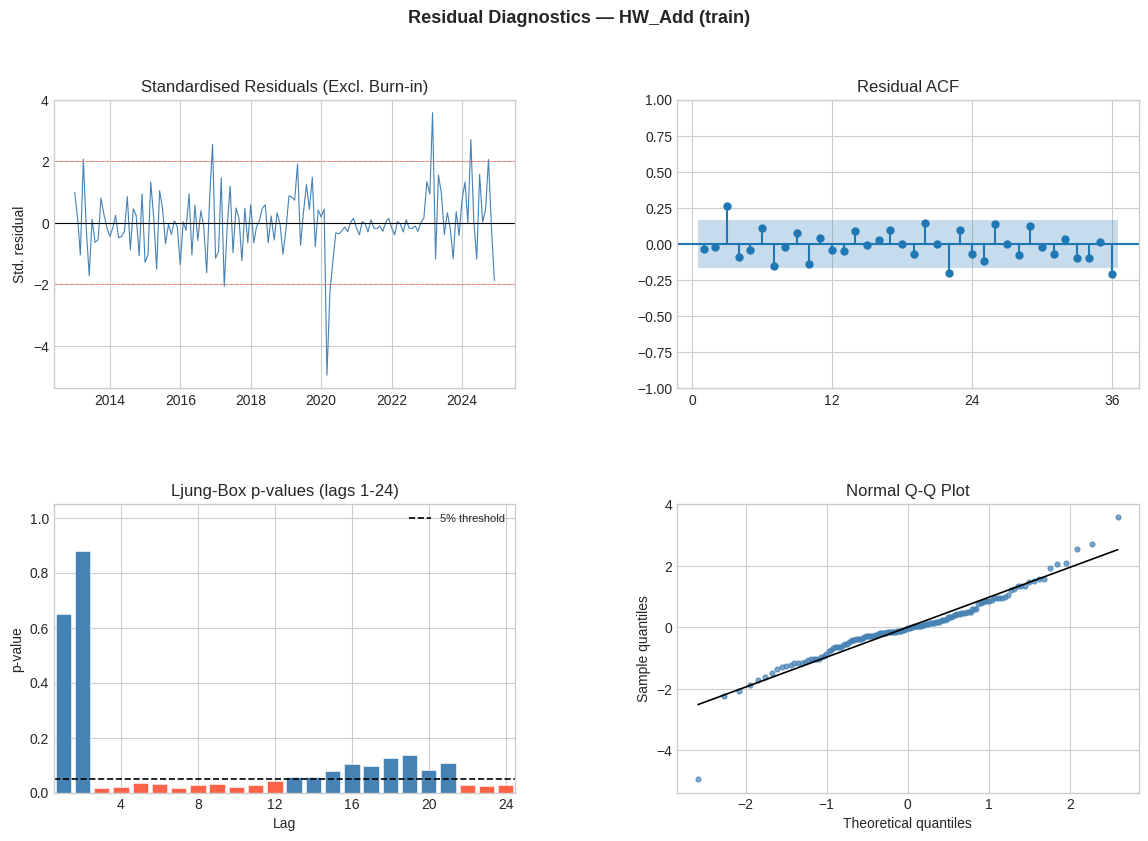

In [48]:
# Loop para os candidatos SARIMA da shortlist
for name in sarima_shortlist:
    if name in sarima_validation_forecasts:
        fit = sarima_validation_forecasts[name]['fit']
        resid = fit.resid
        
        # Extrair a ordem para calcular os graus de liberdade automaticamente
        order, seasonal_order = sarima_shortlist[name]
        df_modelo = order[0] + order[2] + seasonal_order[0] + seasonal_order[2]
        
        save_path = diagnostics_dir / f'residuals_{name}.png'
        
        # Chamada corrigida com df_modelo e corte de 12 meses para o burn_in
        plot_residual_diagnostics(resid, name, save_path, model_df=df_modelo, burn_in=12)

# Para o modelo Holt-Winters (não tem graus de liberdade ARMA clássicos para o Ljung-Box)
hw_add_resid = pd.Series(hw_add.resid, index=train.index)
plot_residual_diagnostics(hw_add_resid, 'HW_Add (train)', diagnostics_dir / 'residuals_HW_Add_train.png', model_df=0, burn_in=12)

## 6. Forecast Evaluation and Comparison

### 6.1 Forecast Evaluation — 2025 Holdout



In [37]:
def error_metrics(y_true, y_pred, naive_mae=None):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    e = y_true - y_pred
    mase = np.mean(np.abs(e)) / naive_mae if naive_mae is not None and naive_mae > 0 else np.nan
    return {
        'ME': np.mean(e),
        'MAE': np.mean(np.abs(e)),
        'MSE': np.mean(e**2),
        'RMSE': np.sqrt(np.mean(e**2)),
        'MAPE_pct': np.mean(np.abs(e / y_true)) * 100,
        'MASE': mase,
    }

# --- Fit SARIMAX(3,1,0)(0,1,1,12) with COVID intervention dummy ---
exog_train_int = pd.Series(0, index=train.index, name='COVID_Shock')
exog_train_int.loc['2020-03':'2022-12'] = 1

model_intervention = SARIMAX(
    train,
    exog=exog_train_int,
    order=(3, 1, 0),
    seasonal_order=(0, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
results_final_train = model_intervention.fit(disp=False)

exog_val_int = pd.Series(0, index=valid.index, name='COVID_Shock')
fc_int = results_final_train.get_forecast(steps=HORIZON, exog=exog_val_int)
sarimax_int_pred = fc_int.predicted_mean
sarimax_int_ci = fc_int.conf_int()

validation_df = pd.DataFrame({'Actual_2025': valid.values}, index=valid.index)
validation_df['SeasonalNaive'] = seasonal_naive_pred
validation_df['HW_Add'] = hw_add_pred.values
validation_df['HW_Mul'] = hw_mul_pred.values
validation_df['HW_Damp_Add'] = hw_dmp_pred.values
validation_df['STL_ETS'] = stl_ets_pred.values

# Add best SARIMA from shortlist by AIC
best_sarima_name = sarima_table.iloc[0]['Model']
validation_df['Best_SARIMA'] = sarima_validation_forecasts[best_sarima_name]['mean'].values
validation_df['Best_SARIMA_Lower_95'] = sarima_validation_forecasts[best_sarima_name]['low'].values
validation_df['Best_SARIMA_Upper_95'] = sarima_validation_forecasts[best_sarima_name]['high'].values

# SARIMAX intervention model
validation_df['SARIMAX_Int'] = sarimax_int_pred.values
validation_df['SARIMAX_Int_Lower_95'] = sarimax_int_ci.iloc[:, 0].values
validation_df['SARIMAX_Int_Upper_95'] = sarimax_int_ci.iloc[:, 1].values

# HW_Add prediction intervals
hw_sigma = hw_add.resid.std(ddof=1)
validation_df['HW_Add_Lower_95'] = validation_df['HW_Add'] - 1.96 * hw_sigma
validation_df['HW_Add_Upper_95'] = validation_df['HW_Add'] + 1.96 * hw_sigma

# Naive MAE for MASE denominator
naive_mae = np.mean(np.abs(valid.values - seasonal_naive_pred))

metric_rows = []
for col in ['SeasonalNaive', 'HW_Add', 'HW_Mul', 'HW_Damp_Add', 'STL_ETS', 'Best_SARIMA', 'SARIMAX_Int']:
    m = error_metrics(validation_df['Actual_2025'], validation_df[col], naive_mae=naive_mae)
    m['Model'] = col
    metric_rows.append(m)

metrics_2025 = pd.DataFrame(metric_rows)[['Model', 'ME', 'MAE', 'MSE', 'RMSE', 'MAPE_pct', 'MASE']].sort_values('MAPE_pct')
metrics_2025

,Model,ME,MAE,MSE,RMSE,MAPE_pct,MASE
5,Best_SARIMA,-231.783988,276.475367,156060.653605,395.045129,3.659215,0.572018
2,HW_Mul,62.973644,295.898079,110469.636918,332.369729,3.805856,0.612203
1,HW_Add,96.789338,312.139613,160743.249872,400.927986,3.864401,0.645806
6,SARIMAX_Int,9.423158,321.815041,160504.079393,400.629604,4.054979,0.665824
3,HW_Damp_Add,157.418727,346.661760,179336.148267,423.480989,4.267489,0.717231
4,STL_ETS,-397.777178,434.929515,264951.994381,514.734878,5.700467,0.899854
0,SeasonalNaive,436.500000,483.333333,326281.833333,571.210848,6.011438,1.000000


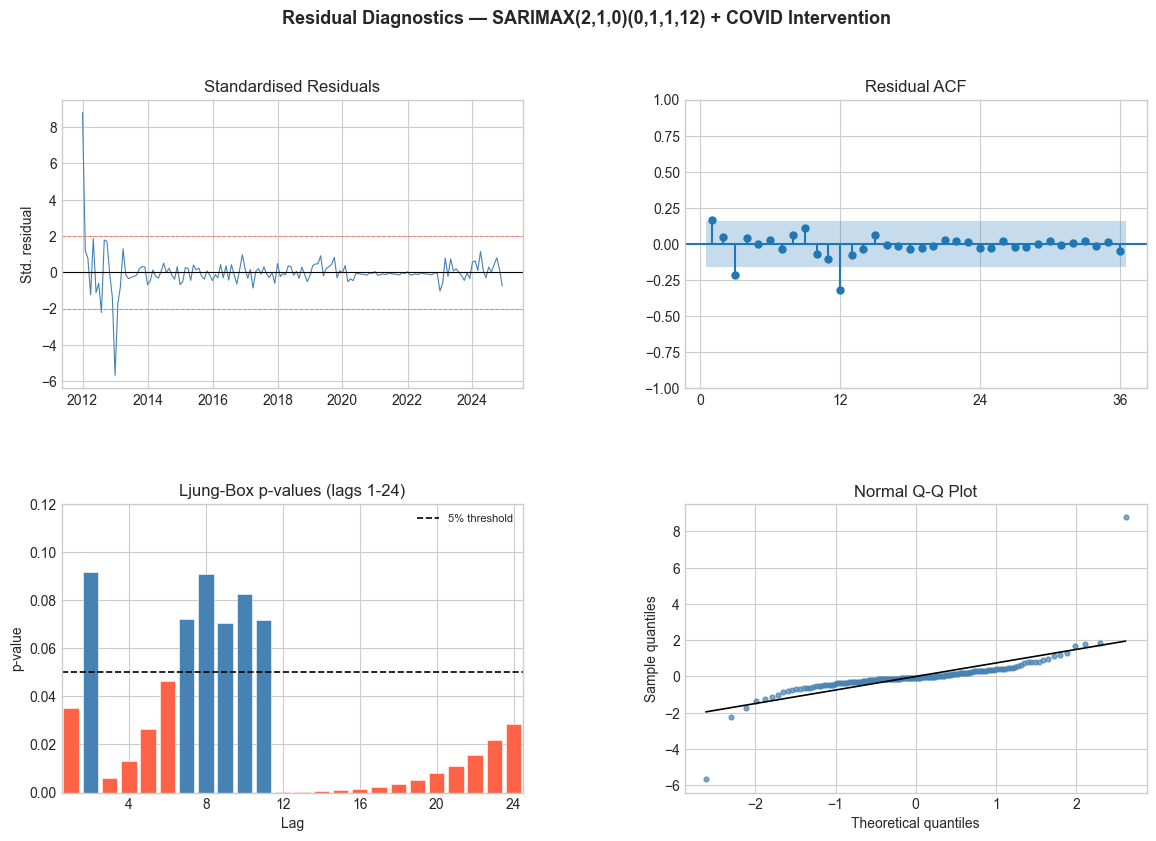

Diagnostics plot saved to: ..\outputs\figures\residuals_SARIMAX_Intervention.png


In [ ]:
import os

os.makedirs(r'..\outputs\figures', exist_ok=True)

# results_final_train is defined in the evaluation cell above
sarimax_resid = results_final_train.resid

save_file = r'..\outputs\figures\residuals_SARIMAX_Intervention.png'

plot_residual_diagnostics(
    resid=sarimax_resid,
    model_name='SARIMAX(2,1,0)(0,1,1,12) + COVID Intervention',
    save_path=save_file
)

print(f'Diagnostics plot saved to: {save_file}')

In [ ]:
# Keep strict order check
assert 'metrics_2025' in globals(), 'Validation metrics must exist before 2026 forecasting.'
assert len(metrics_2025) > 0, 'Validation metrics table is empty.'

selected_model = metrics_2025.iloc[0]['Model']
print(f'Selected model from 2025 validation (lowest MAPE): {selected_model}')
print(f'  Note: if RMSE is the preferred criterion, best model is: {metrics_2025.sort_values("RMSE").iloc[0]["Model"]}')

# --- Empirical PI coverage on 2025 holdout ---
actuals = validation_df['Actual_2025'].values
print('\n--- Empirical Prediction Interval Coverage (2025 holdout, n=12) ---')
for pi_col_lo, pi_col_hi, pi_label in [
    ('Best_SARIMA_Lower_95', 'Best_SARIMA_Upper_95', 'SARIMA 95% PI'),
    ('HW_Add_Lower_95', 'HW_Add_Upper_95', 'HW_Add 95% PI'),
]:
    lo = validation_df[pi_col_lo].values
    hi = validation_df[pi_col_hi].values
    n_inside = np.sum((actuals >= lo) & (actuals <= hi))
    print(f'  {pi_label}: {n_inside}/12 actuals inside  (theoretical expectation: ~11.4)')


Selected model from 2025 validation (lowest MAPE): Best_SARIMA
  Note: if RMSE is the preferred criterion, best model is: HW_Mul

--- Empirical Prediction Interval Coverage (2025 holdout, n=12) ---
  SARIMA 95% PI: 12/12 actuals inside  (theoretical expectation: ~11.4)
  HW_Add 95% PI: 8/12 actuals inside  (theoretical expectation: ~11.4)


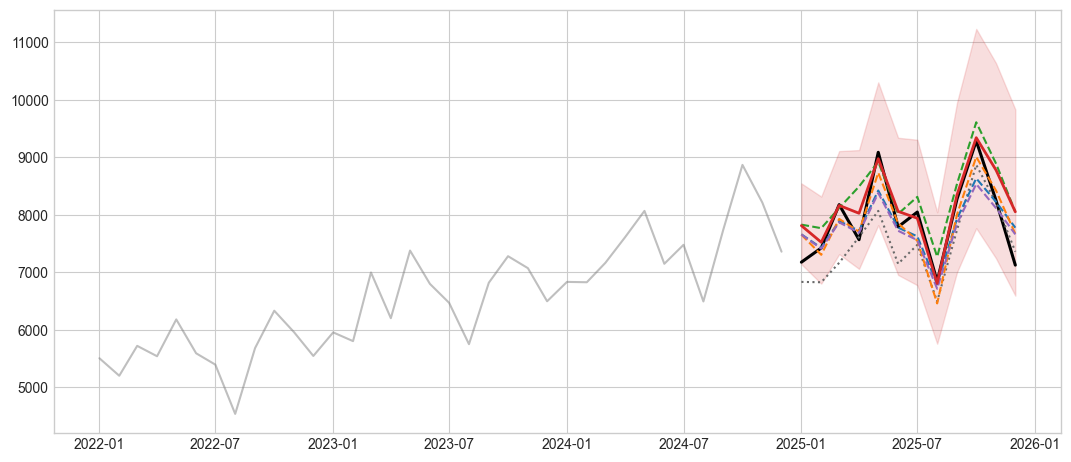

In [ ]:
fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(
    train.index[-36:],
    train.iloc[-36:],
    color="gray",
    alpha=0.5,
    label="Train tail / series_hw (last 36 obs)",
)
ax.plot(
    validation_df.index,
    validation_df["Actual_2025"],
    color="black",
    linewidth=2.2,
    label="Actual 2025",
)
ax.plot(
    validation_df.index,
    validation_df["SeasonalNaive"],
    linestyle=":",
    color="dimgray",
    label="Seasonal Naive",
)
ax.plot(
    validation_df.index,
    validation_df["HW_Add"],
    linestyle="--",
    color="tab:blue",
    label="HW Add",
)
ax.plot(
    validation_df.index,
    validation_df["HW_Mul"],
    linestyle="--",
    color="tab:orange",
    label="HW Mul",
)
ax.plot(
    validation_df.index,
    validation_df["HW_Damp_Add"],
    linestyle="--",
    color="tab:purple",
    label="HW Damp Add",
)
ax.plot(
    validation_df.index,
    validation_df["STL_ETS"],
    linestyle="--",
    color="tab:green",
    label="STL+ETS",
)
ax.plot(
    validation_df.index,
    validation_df["Best_SARIMA"],
    color="tab:red",
    linewidth=2,
    label=f"{best_sarima_name}",
)

ax.fill_between(
    validation_df.index,
    validation_df["Best_SARIMA_Lower_95"],
    validation_df["Best_SARIMA_Upper_95"],
    color="tab:red",
    alpha=0.15,
    label="SARIMA 95% PI",
)

ax.fill_between(
    validation_df.index,
    validation_df["HW_Add_Lower_95"],
    validation_df["HW_Add_Upper_95"],
    color="tab:blue",
    alpha=0
)

In [ ]:
validation_df.to_csv(data_out_dir / 'forecast_2025_validation.csv')
metrics_2025.to_csv(data_out_dir / 'metrics_2025_validation.csv', index=False)
metrics_2025.to_csv(tables_dir / 'metrics_2025_validation.csv', index=False)
print(metrics_2025.to_string(index=False))


        Model          ME        MAE           MSE       RMSE  MAPE_pct     MASE
  Best_SARIMA -231.603056 276.435631 155990.510293 394.956340  3.658758 0.571936
       HW_Mul   62.979865 295.898152 110469.488806 332.369506  3.805854 0.612203
       HW_Add   96.833933 312.115883 160748.294898 400.934278  3.864093 0.645757
  SARIMAX_Int  -13.795926 324.385460 156354.462612 395.416821  4.107139 0.671142
  HW_Damp_Add  157.413686 346.656041 179332.328547 423.476479  4.267419 0.717219
      STL_ETS -397.776363 434.928753 264951.163808 514.734071  5.700457 0.899853
SeasonalNaive  436.500000 483.333333 326281.833333 571.210848  6.011438 1.000000


### 6.2 Validation Results and Model Selection



## 7. Conclusions and Limitations

### 7.1 Benefits and Limitations by Method



### 7.2 Conclusions



## 8. Out-of-Sample Forecasts for 2026

### 8.1 Out-of-Sample Forecasts for 2026



In [ ]:
# 2026 forecast only after 2025 validation is finalized
full_train = series_hw.loc[: pd.Timestamp("2025-12-01")]

# series_hw: COVID-adjusted
if selected_model == "SeasonalNaive":
    fc_values = full_train.iloc[-SEASONAL_PERIOD:].values
    fc_index = pd.date_range(start="2026-01-01", periods=HORIZON, freq="MS")
    fc_mean = pd.Series(fc_values, index=fc_index)

    resid = valid.values - validation_df["SeasonalNaive"].values
    sigma = np.std(resid, ddof=1)

    fc_low = fc_mean - 1.96 * sigma
    fc_up = fc_mean + 1.96 * sigma

elif selected_model in ["HW_Add", "HW_Mul", "HW_Damp_Add"]:
    seasonal_mode = "add" if selected_model != "HW_Mul" else "mul"
    damped = selected_model == "HW_Damp_Add"

    hw_full = ExponentialSmoothing(
        full_train,
        trend="add",
        damped_trend=damped,
        seasonal=seasonal_mode,
        seasonal_periods=SEASONAL_PERIOD,
    ).fit(optimized=True)

    fc_mean = hw_full.forecast(HORIZON)
    sigma = hw_full.resid.std(ddof=1)

    fc_low = fc_mean - 1.96 * sigma
    fc_up = fc_mean + 1.96 * sigma

elif selected_model == "STL_ETS":
    stl_full = STL(full_train, period=SEASONAL_PERIOD, robust=True).fit()
    sa_full = full_train - stl_full.seasonal

    holt_full = Holt(sa_full, damped_trend=False).fit(optimized=True)
    sa_fc = holt_full.forecast(HORIZON)

    last_seas = stl_full.seasonal.iloc[-SEASONAL_PERIOD:].values
    fc_index = pd.date_range(start="2026-01-01", periods=HORIZON, freq="MS")
    fc_mean = pd.Series(sa_fc.values + last_seas, index=fc_index)

    sigma = stl_full.resid.std()

    fc_low = fc_mean - 1.96 * sigma
    fc_up = fc_mean + 1.96 * sigma

else:
    sarima_choice = best_sarima_name
    order, seasonal_order = sarima_shortlist[sarima_choice]

    sarima_full = SARIMAX(
        np.log(full_train),
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False)

    fc = sarima_full.get_forecast(steps=HORIZON)
    fc_mean = np.exp(fc.predicted_mean)
    ci = fc.conf_int(alpha=0.05)

    fc_low = np.exp(ci.iloc[:, 0])
    fc_up = np.exp(ci.iloc[:, 1])

forecast_2026 = pd.DataFrame(
    {
        "Forecast_2026": np.asarray(fc_mean),
        "Lower_95": np.asarray(fc_low),
        "Upper_95": np.asarray(fc_up),
    },
    index=pd.date_range(start="2026-01-01", periods=HORIZON, freq="MS"),
)
forecast_2026.index.name = "Date"

# Also produce SARIMA 2026 forecasts for comparison
sarima_full_2026 = SARIMAX(
    np.log(full_train),
    order=sarima_shortlist[best_sarima_name][0],
    seasonal_order=sarima_shortlist[best_sarima_name][1],
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)

fc_sarima_2026 = sarima_full_2026.get_forecast(steps=HORIZON)
fc_sarima_m = np.exp(fc_sarima_2026.predicted_mean)
ci_sarima = fc_sarima_2026.conf_int(alpha=0.05)

forecast_2026["SARIMA_Forecast"] = fc_sarima_m.values
forecast_2026["SARIMA_Lower_95"] = np.exp(ci_sarima.iloc[:, 0].values)
forecast_2026["SARIMA_Upper_95"] = np.exp(ci_sarima.iloc[:, 1].values)

forecast_2026.to_csv(data_out_dir / "forecast_2026.csv")
display(forecast_2026.round(1))

# Real-world interpretation
print(
    f"\n2026 Annual Implied Total ({selected_model}): {forecast_2026['Forecast_2026'].sum():.0f} thousand passengers"
)

peak_month = forecast_2026["Forecast_2026"].idxmax().strftime("%B")
trough_month = forecast_2026["Forecast_2026"].idxmin().strftime("%B")

print(f"Peak demand month: {peak_month}  |  Trough month: {trough_month}")
print(
    f"Consistent with historical pattern (Oct/Nov peak, Aug trough): {peak_month in ['October', 'November'] and trough_month == 'August'}"
)

actual_2025_total = valid.sum()
print(
    f"2025 actual total: {actual_2025_total:.0f}  |  Implied 2026 change: {((forecast_2026['Forecast_2026'].sum() - actual_2025_total) / actual_2025_total * 100):+.1f}%"
)

,Forecast_2026,Lower_95,Upper_95,SARIMA_Forecast,SARIMA_Lower_95,SARIMA_Upper_95
Date,,,,,,
2026-01-01,7580.8,6929.8,8293.0,7580.8,6929.8,8293.0
2026-02-01,7379.8,6672.5,8162.2,7379.8,6672.5,8162.2
2026-03-01,7989.9,7156.0,8920.9,7989.9,7156.0,8920.9
2026-04-01,7791.5,6849.0,8863.8,7791.5,6849.0,8863.8
2026-05-01,8853.4,7706.9,10170.4,8853.4,7706.9,10170.4
2026-06-01,7841.4,6759.3,9096.7,7841.4,6759.3,9096.7
2026-07-01,7843.4,6685.8,9201.4,7843.4,6685.8,9201.4
2026-08-01,6698.8,5660.4,7927.8,6698.8,5660.4,7927.8
2026-09-01,8185.9,6856.8,9772.5,8185.9,6856.8,9772.5



2026 Annual Implied Total (Best_SARIMA): 95479 thousand passengers
Peak demand month: October  |  Trough month: August
Consistent with historical pattern (Oct/Nov peak, Aug trough): True
2025 actual total: 95019  |  Implied 2026 change: +0.5%


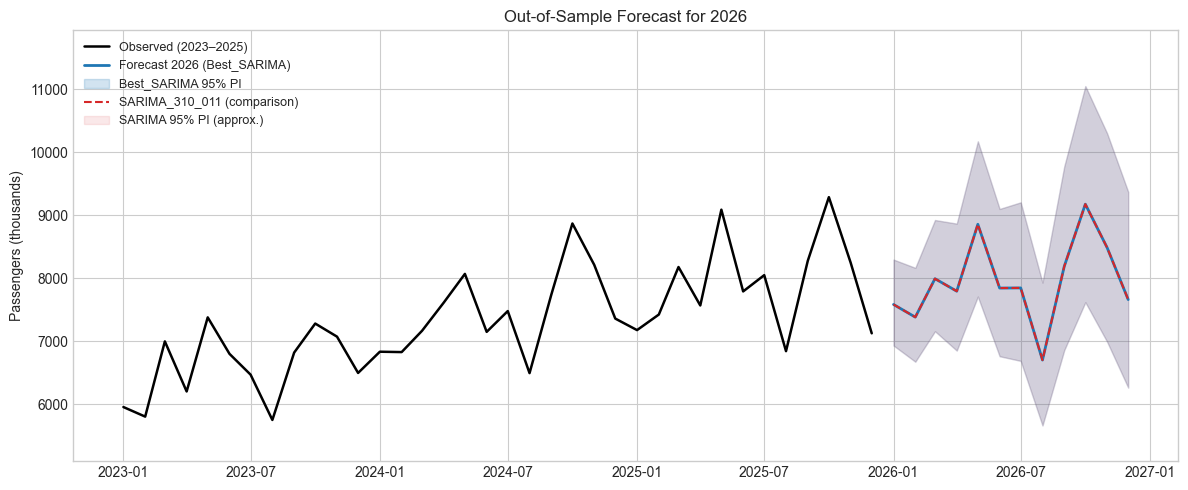

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(full_train.index[-36:], full_train.iloc[-36:], color='black', linewidth=1.8, label='Observed (2023–2025)')
ax.plot(forecast_2026.index, forecast_2026['Forecast_2026'], color='tab:blue', linewidth=2, label=f'Forecast 2026 ({selected_model})')
ax.fill_between(forecast_2026.index, forecast_2026['Lower_95'], forecast_2026['Upper_95'],
                color='tab:blue', alpha=0.2, label=f'{selected_model} 95% PI')
ax.plot(forecast_2026.index, forecast_2026['SARIMA_Forecast'], color='tab:red', linewidth=1.5,
        linestyle='--', label=f'{best_sarima_name} (comparison)')
ax.fill_between(forecast_2026.index, forecast_2026['SARIMA_Lower_95'], forecast_2026['SARIMA_Upper_95'],
                color='tab:red', alpha=0.1, label='SARIMA 95% PI (approx.)')

# Fix y-axis to data range
all_vals = np.concatenate([
    full_train.iloc[-36:].values,
    forecast_2026['Upper_95'].values,
    forecast_2026['Lower_95'].values,
])
ax.set_ylim(max(0, all_vals.min() * 0.90), all_vals.max() * 1.08)

ax.set_title('Out-of-Sample Forecast for 2026')
ax.set_ylabel('Passengers (thousands)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(fig_dir / 'forecast_2026_plot.png', dpi=300)
plt.show()

forecast_2026.to_csv(data_out_dir / 'forecast_2026.csv')


In [ ]:

# Residual diagnostics for selected final model (if SARIMA)
if selected_model == 'Best_SARIMA':
    fit = sarima_validation_forecasts[best_sarima_name]['fit']
    resid = fit.resid.dropna()
    order, seasonal_order = sarima_shortlist[best_sarima_name]
    model_df = order[0] + order[2] + seasonal_order[0] + seasonal_order[2]
    lb = acorr_ljungbox(resid, lags=[12, 24], model_df=model_df, return_df=True)
    lb.to_csv(diagnostics_dir / 'residual_ljung_box.csv')
    pd.DataFrame({'residual': resid}).to_csv(diagnostics_dir / 'residual_series.csv', index=False)
    display(lb)
else:
    resid = validation_df['Actual_2025'] - validation_df[selected_model]
    safe_lag = max(1, min(10, len(resid)-1))
    lb = acorr_ljungbox(resid, lags=[safe_lag], return_df=True)
    lb.to_csv(diagnostics_dir / 'residual_ljung_box.csv')
    pd.DataFrame({'residual': resid}).to_csv(diagnostics_dir / 'residual_series.csv', index=False)
    display(lb)


,lb_stat,lb_pvalue
12,43.356255,7.526258e-07
24,46.482855,6.916767e-04


In [ ]:
artifacts = [
    fig_dir / 'eda_time_plot.png',
    fig_dir / 'eda_month_profile.png',
    fig_dir / 'eda_acf_pacf_raw.png',
    fig_dir / 'eda_seasonal_subseries.png',
    fig_dir / 'eda_original_vs_adjusted.png',
    fig_dir / 'eda_covid_ratio.png',
    fig_dir / 'stl_decomposition_train.png',
    fig_dir / 'sarima_identification_acf_pacf.png',
    fig_dir / 'validation_2025_plot.png',
    fig_dir / 'forecast_2026_plot.png',
    data_out_dir / 'forecast_2025_validation.csv',
    data_out_dir / 'metrics_2025_validation.csv',
    data_out_dir / 'forecast_2026.csv',
    tables_dir / 'sarima_shortlist_aic_bic.csv',
    tables_dir / 'sarima_best_coefficients.csv',
    tables_dir / 'stl_components_train.csv',
    tables_dir / 'smoothing_estimation_results.csv',
    tables_dir / 'metrics_2025_validation.csv',
    tables_dir / 'covid_impact_ratios.csv',
    diagnostics_dir / 'residual_ljung_box.csv',
    *[diagnostics_dir / f'residuals_{name}.png' for name in sarima_shortlist],
    diagnostics_dir / 'residuals_HW_Add_train.png',
]

pd.DataFrame({'file': [str(p) for p in artifacts], 'exists': [p.exists() for p in artifacts]})


,file,exists
0,..\outputs\figures\eda_time_plot.png,True
1,..\outputs\figures\eda_month_profile.png,True
2,..\outputs\figures\eda_acf_pacf_raw.png,True
3,..\outputs\figures\eda_seasonal_subseries.png,True
4,..\outputs\figures\eda_original_vs_adjusted.png,False
5,..\outputs\figures\eda_covid_ratio.png,False
6,..\outputs\figures\stl_decomposition_train.png,True
7,..\outputs\figures\sarima_identification_acf_p...,True
8,..\outputs\figures\validation_2025_plot.png,False
9,..\outputs\figures\forecast_2026_plot.png,True


### Appendix — Output Files

All intermediate and final outputs are saved for full traceability:

**Tables** (`outputs/tables/`):
- `metrics_2025_validation.csv` — ME, MAE, RMSE, MAPE, MASE for all 6 models on the 2025 holdout.
- `sarima_shortlist_aic_bic.csv` — AIC, AICc, BIC, Ljung-Box p-values for all 5 SARIMA candidates.
- `sarima_best_coefficients.csv` — coefficients, std errors, t-stats, p-values for SARIMA(3,1,0)(0,1,1,12).
- `smoothing_estimation_results.csv` — α, β, γ, φ, SSE for all Holt-Winters variants.
- `stl_components_train.csv` — STL trend, seasonal, remainder, seasonally-adjusted series (training data).
- `covid_adjusted_series.csv` — original series alongside all three COVID-adjusted variants.
- `HW_report.csv` — fitted values and seasonally-adjusted series from the COVID counterfactual HW model.
- `Forecast_Comparison.csv` — COVID counterfactual evaluation (2019–2022 projection vs actual).

**Data** (`outputs/data/`):
- `forecast_2025_validation.csv` — all model forecasts vs actual for 2025, with prediction intervals.
- `metrics_2025_validation.csv` — duplicate of table above, saved to data folder for pipeline use.
- `forecast_2026.csv` — 2026 point forecasts and 95% prediction intervals for selected model.

**Figures** (`outputs/figures/`):
- `eda_time_plot.png`, `eda_month_profile.png`, `eda_seasonal_subseries.png` — EDA plots.
- `eda_acf_pacf_raw.png` — ACF/PACF of the original COVID-adjusted series.
- `stl_decomposition_train.png` — STL four-panel decomposition.
- `sarima_identification_acf_pacf.png` — ACF/PACF of doubly-differenced log series.
- `comparativo_modelos_covid.png` — COVID counterfactual comparison (2015–2022).
- `residuals_*.png` — four-panel residual diagnostics for each SARIMA candidate and HW_Add.